In [ ]:
# ==========================================
# BERTopic Topic Modeling theo Sentiment
# WildAct Facebook Comments
# ==========================================

# !pip install bertopic umap-learn hdbscan sentence-transformers gensim scikit-learn

import pandas as pd

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

from sklearn.feature_extraction.text import CountVectorizer

from umap import UMAP
from hdbscan import HDBSCAN

from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# ==========================================
# 1. LOAD DATA
# ==========================================

input_file = "/content/final_training_data_cleaned_v3.csv"

df = pd.read_csv(input_file)

print("Tổng số dòng:", len(df))

# ==========================================
# 2. REMOVE EMPTY + SHORT COMMENTS
# ==========================================

# ==========================================
# 2. REMOVE EMPTY + SHORT COMMENTS
# ==========================================

# bỏ NaN
df = df[df["cleaned_text"].notna()].copy()

# convert string
df["cleaned_text"] = (
    df["cleaned_text"]
    .astype(str)
    .str.strip()
)

# bỏ chuỗi rỗng
df = df[
    df["cleaned_text"] != ""
]

# bỏ literal "nan"
df = df[
    df["cleaned_text"].str.lower() != "nan"
]

# bỏ comment quá ngắn
df = df[
    df["cleaned_text"]
    .str.split()
    .str.len() >= 4
]

# reset index
df = df.reset_index(drop=True)

print("Sau lọc:", len(df))
# ==========================================
# 3. EMBEDDING MODEL
# ==========================================

# embedding_model = SentenceTransformer(
#     "paraphrase-multilingual-MiniLM-L12-v2"
# )


embedding_model = SentenceTransformer("keepitreal/vietnamese-sbert")

# ==========================================
# 4. STOPWORDS
# ==========================================

custom_stopwords = [

    # =========================
    # PRONOUNS
    # =========================
    "mình", "người", "tôi", "họ", "nó",
    "bạn", "anh", "chị", "em",

    # =========================
    # COMMON WORDS
    # =========================
    "và", "để", "như", "trong", "với",
    "của", "một", "này", "đó",

    "cái", "mấy", "bọn",
    "các", "những",

    "không", "gì", "đâu", "chưa",
    "sao", "thế", "nào",

    "rất", "nhiều", "quá", "lắm",

    "ơi", "ạ", "nhỉ", "nhé",

    "thấy", "đi", "sẽ", "cũng",
    "còn", "nói", "lại", "phải",

    "đang", "đã", "được",
    "có", "là", "thì", "mà",

    # =========================
    # GENERIC
    # =========================
    "làm",
    "mới",
    "về",
    "đến",
    "ra",
    "khi",
    "theo",
    "hơn",
    "việc",
    "nhưng",
    "vẫn",
    "giờ",
    "ngày",
    "năm",
    "vào",
    "ta",
    "con",

    # =========================
    # GENERIC FEELINGS
    # =========================
    "thích",
    "yêu",
    "hay",
    "vừa",
    "biết",
    "cần",
    "bài",
    "chỉ",
    "bị",
    "hết",
    "vì",

    # =========================
    # SOCIAL CHATTER
    # =========================
    "xin",
    "mong",
    "nghênh",
    "hoan",

    # =========================
    # FACEBOOK CHAT
    # =========================
    "nh",
    "đê",
    "dạ",
    "vầy",
    "vứi",

    # =========================
    # ENTITY / PERSON NAMES
    # =========================
    "wildact",
    "wild",

    "nga",
    "linh",
    "trần",
    "ngọc",
    "thanh",

    # =========================
    # RANDOM NOISE
    # =========================
    "share",
    "gg",
    "ấn",
    "bấm",

    "cô",
    "cháu",

    "đáp_án",
    "mãi",

    "trung_tâm",
    "thông_tin",

    "đăng_ký",

    "hoàn_thành",

    "thời_điểm",


    ##########
    "sớm",
    "tm",
  "vl",
  "má",
  "hả",
  "ủa",
  "tr",
  "kiểu",
  "cho",
  "đó",
  "cứ",
    "đúng",
"nên",
"chứ",
"đấy",
"thật_sự",
"cả",
"lên",
"cùng",
"sự",
"ai",
"có_thể",
"bởi",
"từ",


#######

     "đưa",
    "sống",
    "bảo",
    "nghĩ",

    "facebook",
    "trang",

    "đúng",

    "di",
    "đà",
    "phật",

    "việt_nam",


################################## chỗ nãy nãy ngon
     # generic emotional
    "thật",
    "tốt",
    "nhất",

    # social chatter
    "đọc",
    "lời",

    # event specific
    "city",
    "apply",
    "ezoo",

    # slang/chat
    "dm",
    "đm",
    "dùm",
    "ạa",

    # generic weak semantics
    "gái",
    "nguyen",
    "siêu",
    "vụ",
    "từng",
    "dành",
    "ấy",
    "tụi",
    "tới",

    # malformed tokens
    "ba",
    "la",
    "đa",
    "giơ",
    "na",
    "thê",
    "vâ",
    "vi",

    # weak/noisy
    "giàu",
    "tên",
    "củ"
]



# umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
# hdbscan_model = HDBSCAN(min_cluster_size=5, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
# vectorizer_model = CountVectorizer(stop_words=custom_stopwords, ngram_range=(1, 2))

# ==========================================
# 5. VECTORIZE / UMAP / HDBSCAN
# ==========================================

vectorizer_model = CountVectorizer(

    stop_words=custom_stopwords,

    ngram_range=(1, 2),

    min_df=2,

    max_df=0.9
)

umap_model = UMAP(

    n_neighbors=15,

    n_components=5,

    min_dist=0.1,

    metric='cosine',

    random_state=42
)

hdbscan_model = HDBSCAN(

    min_cluster_size=10,

       min_samples=7,

    metric='euclidean',

    cluster_selection_method='eom',

    prediction_data=True
)

# ==========================================
# 6. FUNCTION CHẠY TOPIC MODELING
# ==========================================

def run_topic_modeling(
    input_df,
    sentiment_name,
    output_prefix,
    nr_topics=8
):

    print("\n")
    print("=" * 70)
    print(f"TOPIC MODELING - {sentiment_name}")
    print("=" * 70)

    documents = (
        input_df["cleaned_text"]
        .astype(str)
        .tolist()
    )

    print(f"Số lượng comments: {len(documents)}")

    # ======================================
    # BERTopic
    # ======================================

    topic_model = BERTopic(

        embedding_model=embedding_model,

        vectorizer_model=vectorizer_model,

        umap_model=umap_model,

        hdbscan_model=hdbscan_model,

        language="multilingual",

        calculate_probabilities=True,

        top_n_words=10,

        verbose=True
    )

    # ======================================
    # TRAIN
    # ======================================

    print("\nĐang train BERTopic...")

    topics, probs = topic_model.fit_transform(documents)

    # ======================================
    # TOPIC INFO
    # ======================================

    topic_info = (
        topic_model
        .get_topic_info()
        .sort_values("Topic")
    )

    print("\n--- KẾT QUẢ TOPIC MODELING ---")

    topic_rows = []

    for _, row in topic_info.iterrows():

        topic_id = row["Topic"]

        topic_count = row["Count"]

        words = topic_model.get_topic(topic_id)

        if words is None:
            continue

        keywords = [
            word
            for word, score in words[:10]
        ]

        keyword_text = ", ".join(keywords)

        # ==============================
        # PRINT
        # ==============================

        if topic_id == -1:

            print(
                f"\n[Topic -1] "
                f"(Nhiễu/Outliers - {topic_count} bình luận)"
            )

        else:

            print(
                f"\n[Topic {topic_id}] "
                f"(Số lượng: {topic_count} bình luận)"
            )

        print(f"➜ 10 từ khóa: {keyword_text}")

        # ==============================
        # SAVE
        # ==============================

        topic_rows.append({

            "Topic": topic_id,

            "Count": topic_count,

            "Keywords": keyword_text
        })

    # ======================================
    # COHERENCE
    # ======================================

    print("\nĐang tính toán chỉ số C_v Coherence...")

    tokenized_docs = [
        doc.split()
        for doc in documents
    ]

    dictionary = Dictionary(tokenized_docs)

    valid_topics = [

        topic
        for topic in topic_model.get_topics().keys()
        if topic != -1
    ]

    topic_words = []

    for topic_id in valid_topics:

        words = topic_model.get_topic(topic_id)

        keywords = [
            word
            for word, score in words[:10]
        ]

        topic_words.append(keywords)

    coherence_model = CoherenceModel(

        topics=topic_words,

        texts=tokenized_docs,

        dictionary=dictionary,

        coherence='c_v'
    )

    coherence_score = (
        coherence_model.get_coherence()
    )

    print(
        f"Chỉ số Topic Coherence (C_v): "
        f"{coherence_score:.4f}"
    )

    # ======================================
    # EXPORT RESULT CSV
    # ======================================

    result_df = input_df.copy()

    result_df["Topic"] = topics

    result_file = (
        f"{output_prefix}_Topic_Result.csv"
    )

    result_df.to_csv(

        result_file,

        index=False,

        encoding="utf-8-sig"
    )

    print(f"\nSaved: {result_file}")

    # ======================================
    # EXPORT KEYWORDS
    # ======================================

    topic_df = pd.DataFrame(topic_rows)

    keyword_file = (
        f"{output_prefix}_Topic_Keywords.csv"
    )

    topic_df.to_csv(

        keyword_file,

        index=False,

        encoding="utf-8-sig"
    )

    print(f"Saved: {keyword_file}")



    return topic_model


# ==========================================
# 7. CHIA DATA THEO SENTIMENT
# ==========================================

# label:
# 1 = positive
# 0 = negative
# 2 = neutral / unrelated

positive_df = df[df["Label"] == 1]

negative_df = df[df["Label"] == 0]

neutral_df = df[df["Label"] == 2]

print("\nPositive comments:", len(positive_df))
print("Negative comments:", len(negative_df))
print("Neutral comments:", len(neutral_df))

# ==========================================
# 8. TOPIC MODELING - POSITIVE
# ==========================================

positive_model = run_topic_modeling(

    input_df=positive_df,

    sentiment_name="POSITIVE COMMENTS",

    output_prefix="Positive",

    nr_topics=8
)

# ==========================================
# 9. TOPIC MODELING - NEGATIVE
# ==========================================

negative_model = run_topic_modeling(

    input_df=negative_df,

    sentiment_name="NEGATIVE COMMENTS",

    output_prefix="Negative",

    nr_topics=8
)

# ==========================================
# OPTIONAL:
# TOPIC MODELING - NEUTRAL
# ==========================================

# neutral_model = run_topic_modeling(
#
#     input_df=neutral_df,
#
#     sentiment_name="NEUTRAL COMMENTS",
#
#     output_prefix="Neutral",
#
#     nr_topics=6
# )

Tổng số dòng: 2430
Sau lọc: 2006


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: keepitreal/vietnamese-sbert
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-21 11:17:38,991 - BERTopic - Embedding - Transforming documents to embeddings.



Positive comments: 923
Negative comments: 766
Neutral comments: 317


TOPIC MODELING - POSITIVE COMMENTS
Số lượng comments: 923

Đang train BERTopic...


Batches:   0%|          | 0/29 [00:00<?, ?it/s]

...

2026-05-21 11:17:45,689 - BERTopic - Embedding - Transforming documents to embeddings.



Saved: Positive_Topic_Result.csv
Saved: Positive_Topic_Keywords.csv


TOPIC MODELING - NEGATIVE COMMENTS
Số lượng comments: 766

Đang train BERTopic...


Batches:   0%|          | 0/24 [00:00<?, ?it/s]

2026-05-21 11:17:47,901 - BERTopic - Embedding - Completed ✓
2026-05-21 11:17:47,903 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-21 11:17:50,310 - BERTopic - Dimensionality - Completed ✓
2026-05-21 11:17:50,312 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-21 11:17:50,361 - BERTopic - Cluster - Completed ✓
2026-05-21 11:17:50,365 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-21 11:17:50,401 - BERTopic - Representation - Completed ✓



--- KẾT QUẢ TOPIC MODELING ---

[Topic -1] (Nhiễu/Outliers - 289 bình luận)
➜ 10 từ khóa: ác, thú, thằng, trời, nuôi, mô_hình, hiểu, ăn, chiếm_đoạt, nữa

[Topic 0] (Số lượng: 198 bình luận)
➜ 10 từ khóa: chim, rừng, bắt, bẫy, bảo_vệ, lưới, kiểm_lâm, bán, phá, nuôi

[Topic 1] (Số lượng: 72 bình luận)
➜ 10 từ khóa: thú, động_vật, vườn thú, vườn, mô_hình, nhốt, nhìn, stress, hiểu, bé

[Topic 2] (Số lượng: 36 bình luận)
➜ 10 từ khóa: buồn, chúc, nghe, cơ_hội, hạnh_phúc, ám_ảnh, tham_gia, chán, nữa, chả

[Topic 3] (Số lượng: 30 bình luận)
➜ 10 từ khóa: trên, địa_chỉ, ca, câu, kinh_doanh, chia_sẻ, co, ti, mô, ngươ

[Topic 4] (Số lượng: 29 bình luận)
➜ 10 từ khóa: ăn, ngon, gà, con_cò, thịt, đói, ăn chim, ăn ăn, chuẩn_bị, đồ_ăn

[Topic 5] (Số lượng: 29 bình luận)
➜ 10 từ khóa: loài, động_vật, ác, tàn_ác, tàn_nhẫn, chúng, kẻ, ác_nhân, yêu_thương, lợi_ích

[Topic 6] (Số lượng: 20 bình luận)
➜ 10 từ khóa: ác, ác ác, khốn_nạn, gặt quả, bất_nhân, kẻ ác, loài ác, đau_lòng, nhẫn_tâm, gặt

[Topic 7]

In [ ]:
# ==========================================
# BERTopic Topic Modeling theo Sentiment
# WildAct Facebook Comments
# ==========================================

# !pip install bertopic umap-learn hdbscan sentence-transformers gensim scikit-learn

import pandas as pd

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

from sklearn.feature_extraction.text import CountVectorizer

from umap import UMAP
from hdbscan import HDBSCAN

from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# ==========================================
# 1. LOAD DATA
# ==========================================

input_file = "/content/final_training_data_cleaned_v3.csv"

df = pd.read_csv(input_file)

print("Tổng số dòng:", len(df))

# ==========================================
# 2. REMOVE EMPTY + SHORT COMMENTS
# ==========================================

# ==========================================
# 2. REMOVE EMPTY + SHORT COMMENTS
# ==========================================

# bỏ NaN
df = df[df["cleaned_text"].notna()].copy()

# convert string
df["cleaned_text"] = (
    df["cleaned_text"]
    .astype(str)
    .str.strip()
)

# bỏ chuỗi rỗng
df = df[
    df["cleaned_text"] != ""
]

# bỏ literal "nan"
df = df[
    df["cleaned_text"].str.lower() != "nan"
]

# bỏ comment quá ngắn
df = df[
    df["cleaned_text"]
    .str.split()
    .str.len() >= 4
]

# reset index
df = df.reset_index(drop=True)

print("Sau lọc:", len(df))
# ==========================================
# 3. EMBEDDING MODEL
# ==========================================

# embedding_model = SentenceTransformer(
#     "paraphrase-multilingual-MiniLM-L12-v2"
# )


embedding_model = SentenceTransformer("keepitreal/vietnamese-sbert")

# ==========================================
# 4. STOPWORDS
# ==========================================

custom_stopwords = [

    # =========================
    # PRONOUNS
    # =========================
    "mình", "người", "tôi", "họ", "nó",
    "bạn", "anh", "chị", "em",

    # =========================
    # COMMON WORDS
    # =========================
    "và", "để", "như", "trong", "với",
    "của", "một", "này", "đó",

    "cái", "mấy", "bọn",
    "các", "những",

    "không", "gì", "đâu", "chưa",
    "sao", "thế", "nào",

    "rất", "nhiều", "quá", "lắm",

    "ơi", "ạ", "nhỉ", "nhé",

    "thấy", "đi", "sẽ", "cũng",
    "còn", "nói", "lại", "phải",

    "đang", "đã", "được",
    "có", "là", "thì", "mà",

    # =========================
    # GENERIC
    # =========================
    "làm",
    "mới",
    "về",
    "đến",
    "ra",
    "khi",
    "theo",
    "hơn",
    "việc",
    "nhưng",
    "vẫn",
    "giờ",
    "ngày",
    "năm",
    "vào",
    "ta",
    "con",

    # =========================
    # GENERIC FEELINGS
    # =========================
    "thích",
    "yêu",
    "hay",
    "vừa",
    "biết",
    "cần",
    "bài",
    "chỉ",
    "bị",
    "hết",
    "vì",

    # =========================
    # SOCIAL CHATTER
    # =========================
    "xin",
    "mong",
    "nghênh",
    "hoan",

    # =========================
    # FACEBOOK CHAT
    # =========================
    "nh",
    "đê",
    "dạ",
    "vầy",
    "vứi",

    # =========================
    # ENTITY / PERSON NAMES
    # =========================
    "wildact",
    "wild",

    "nga",
    "linh",
    "trần",
    "ngọc",
    "thanh",

    # =========================
    # RANDOM NOISE
    # =========================
    "share",
    "gg",
    "ấn",
    "bấm",

    "cô",
    "cháu",

    "đáp_án",
    "mãi",

    "trung_tâm",
    "thông_tin",

    "đăng_ký",

    "hoàn_thành",

    "thời_điểm",


    ##########
    "sớm",
    "tm",
  "vl",
  "má",
  "hả",
  "ủa",
  "tr",
  "kiểu",
  "cho",
  "đó",
  "cứ",
    "đúng",
"nên",
"chứ",
"đấy",
"thật_sự",
"cả",
"lên",
"cùng",
"sự",
"ai",
"có_thể",
"bởi",
"từ",


#######

     "đưa",
    "sống",
    "bảo",
    "nghĩ",

    "facebook",
    "trang",

    "đúng",

    "di",
    "đà",
    "phật",

    "việt_nam",


################################## chỗ nãy nãy ngon
     # generic emotional
    "thật",
    "tốt",
    "nhất",

    # social chatter
    "đọc",
    "lời",

    # event specific
    "city",
    "apply",
    "ezoo",

    # slang/chat
    "dm",
    "đm",
    "dùm",
    "ạa",

    # generic weak semantics
    "gái",
    "nguyen",
    "siêu",
    "vụ",
    "từng",
    "dành",
    "ấy",
    "tụi",
    "tới",

    # malformed tokens
    "ba",
    "la",
    "đa",
    "giơ",
    "na",
    "thê",
    "vâ",
    "vi",

    # weak/noisy
    "giàu",
    "tên",
    "củ"
]



# umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
# hdbscan_model = HDBSCAN(min_cluster_size=5, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
# vectorizer_model = CountVectorizer(stop_words=custom_stopwords, ngram_range=(1, 2))

# ==========================================
# 5. VECTORIZE / UMAP / HDBSCAN
# ==========================================

vectorizer_model = CountVectorizer(

    stop_words=custom_stopwords,

    ngram_range=(1, 2),

    min_df=2,

    max_df=0.9
)

umap_model = UMAP(

    n_neighbors=15,

    n_components=5,

    min_dist=0.1,

    metric='cosine',

    random_state=42
)

hdbscan_model = HDBSCAN(

    min_cluster_size=10,

       min_samples=6,

    metric='euclidean',

    cluster_selection_method='eom',

    prediction_data=True
)

# ==========================================
# 6. FUNCTION CHẠY TOPIC MODELING
# ==========================================

def run_topic_modeling(
    input_df,
    sentiment_name,
    output_prefix,
    nr_topics=8
):

    print("\n")
    print("=" * 70)
    print(f"TOPIC MODELING - {sentiment_name}")
    print("=" * 70)

    documents = (
        input_df["cleaned_text"]
        .astype(str)
        .tolist()
    )

    print(f"Số lượng comments: {len(documents)}")

    # ======================================
    # BERTopic
    # ======================================

    topic_model = BERTopic(

        embedding_model=embedding_model,

        vectorizer_model=vectorizer_model,

        umap_model=umap_model,

        hdbscan_model=hdbscan_model,

        language="multilingual",

        calculate_probabilities=True,

        top_n_words=10,

        verbose=True
    )

    # ======================================
    # TRAIN
    # ======================================

    print("\nĐang train BERTopic...")

    topics, probs = topic_model.fit_transform(documents)

    # ======================================
    # TOPIC INFO
    # ======================================

    topic_info = (
        topic_model
        .get_topic_info()
        .sort_values("Topic")
    )

    print("\n--- KẾT QUẢ TOPIC MODELING ---")

    topic_rows = []

    for _, row in topic_info.iterrows():

        topic_id = row["Topic"]

        topic_count = row["Count"]

        words = topic_model.get_topic(topic_id)

        if words is None:
            continue

        keywords = [
            word
            for word, score in words[:10]
        ]

        keyword_text = ", ".join(keywords)

        # ==============================
        # PRINT
        # ==============================

        if topic_id == -1:

            print(
                f"\n[Topic -1] "
                f"(Nhiễu/Outliers - {topic_count} bình luận)"
            )

        else:

            print(
                f"\n[Topic {topic_id}] "
                f"(Số lượng: {topic_count} bình luận)"
            )

        print(f"➜ 10 từ khóa: {keyword_text}")

        # ==============================
        # SAVE
        # ==============================

        topic_rows.append({

            "Topic": topic_id,

            "Count": topic_count,

            "Keywords": keyword_text
        })

    # ======================================
    # COHERENCE
    # ======================================

    print("\nĐang tính toán chỉ số C_v Coherence...")

    tokenized_docs = [
        doc.split()
        for doc in documents
    ]

    dictionary = Dictionary(tokenized_docs)

    valid_topics = [

        topic
        for topic in topic_model.get_topics().keys()
        if topic != -1
    ]

    topic_words = []

    for topic_id in valid_topics:

        words = topic_model.get_topic(topic_id)

        keywords = [
            word
            for word, score in words[:10]
        ]

        topic_words.append(keywords)

    coherence_model = CoherenceModel(

        topics=topic_words,

        texts=tokenized_docs,

        dictionary=dictionary,

        coherence='c_v'
    )

    coherence_score = (
        coherence_model.get_coherence()
    )

    print(
        f"Chỉ số Topic Coherence (C_v): "
        f"{coherence_score:.4f}"
    )

    # ======================================
    # EXPORT RESULT CSV
    # ======================================

    result_df = input_df.copy()

    result_df["Topic"] = topics

    result_file = (
        f"{output_prefix}_Topic_Result.csv"
    )

    result_df.to_csv(

        result_file,

        index=False,

        encoding="utf-8-sig"
    )

    print(f"\nSaved: {result_file}")

    # ======================================
    # EXPORT KEYWORDS
    # ======================================

    topic_df = pd.DataFrame(topic_rows)

    keyword_file = (
        f"{output_prefix}_Topic_Keywords.csv"
    )

    topic_df.to_csv(

        keyword_file,

        index=False,

        encoding="utf-8-sig"
    )

    print(f"Saved: {keyword_file}")



    return topic_model


# ==========================================
# 7. CHIA DATA THEO SENTIMENT
# ==========================================

# label:
# 1 = positive
# 0 = negative
# 2 = neutral / unrelated

positive_df = df[df["Label"] == 1]

negative_df = df[df["Label"] == 0]

neutral_df = df[df["Label"] == 2]

print("\nPositive comments:", len(positive_df))
print("Negative comments:", len(negative_df))
print("Neutral comments:", len(neutral_df))

# ==========================================
# 8. TOPIC MODELING - POSITIVE
# ==========================================

# positive_model = run_topic_modeling(

#     input_df=positive_df,

#     sentiment_name="POSITIVE COMMENTS",

#     output_prefix="Positive",

#     nr_topics=8
# )

# ==========================================
# 9. TOPIC MODELING - NEGATIVE
# ==========================================

negative_model = run_topic_modeling(

    input_df=negative_df,

    sentiment_name="NEGATIVE COMMENTS",

    output_prefix="Negative",

    nr_topics=8
)

# ==========================================
# OPTIONAL:
# TOPIC MODELING - NEUTRAL
# ==========================================

# neutral_model = run_topic_modeling(
#
#     input_df=neutral_df,
#
#     sentiment_name="NEUTRAL COMMENTS",
#
#     output_prefix="Neutral",
#
#     nr_topics=6
# )

Tổng số dòng: 2430
Sau lọc: 2006


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: keepitreal/vietnamese-sbert
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-21 11:19:39,238 - BERTopic - Embedding - Transforming documents to embeddings.



Positive comments: 923
Negative comments: 766
Neutral comments: 317


TOPIC MODELING - NEGATIVE COMMENTS
Số lượng comments: 766

Đang train BERTopic...


Batches:   0%|          | 0/24 [00:00<?, ?it/s]

2026-05-21 11:19:41,418 - BERTopic - Embedding - Completed ✓
2026-05-21 11:19:41,420 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-21 11:19:44,664 - BERTopic - Dimensionality - Completed ✓
2026-05-21 11:19:44,666 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-21 11:19:44,721 - BERTopic - Cluster - Completed ✓
2026-05-21 11:19:44,725 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-21 11:19:44,766 - BERTopic - Representation - Completed ✓



--- KẾT QUẢ TOPIC MODELING ---

[Topic -1] (Nhiễu/Outliers - 253 bình luận)
➜ 10 từ khóa: ác, thú, mô_hình, hiểu, nuôi, động_vật, vãi, sợ, đây, thằng

[Topic 0] (Số lượng: 200 bình luận)
➜ 10 từ khóa: chim, rừng, bắt, bẫy, bảo_vệ, lưới, kiểm_lâm, bán, nuôi, phá

[Topic 1] (Số lượng: 73 bình luận)
➜ 10 từ khóa: thú, động_vật, vườn thú, vườn, nhốt, mô_hình, nhìn, stress, bé, liên_tục

[Topic 2] (Số lượng: 40 bình luận)
➜ 10 từ khóa: buồn, nghe, điện_thoại, cơ_hội, tiếc, chúc, kêu, làm_sao, nữa, hạnh_phúc

[Topic 3] (Số lượng: 31 bình luận)
➜ 10 từ khóa: ăn, ngon, gà, đói, con_cò, thịt, ăn chim, ăn ăn, miếng, đồ_ăn

[Topic 4] (Số lượng: 29 bình luận)
➜ 10 từ khóa: trên, comment, địa_chỉ, ca, câu, kinh_doanh, chia_sẻ, ngươ, lỡ, mô

[Topic 5] (Số lượng: 28 bình luận)
➜ 10 từ khóa: loài, động_vật, ác, tàn_ác, tàn_nhẫn, chúng, kẻ, yêu_thương, lợi_ích, độc_ác

[Topic 6] (Số lượng: 21 bình luận)
➜ 10 từ khóa: ác, ác ác, ác_nhân, khốn_nạn, lũ, gặt quả, bất_nhân, kẻ ác, trừng_trị, ác ác_nhân

[T

In [28]:
import pandas as pd
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Tắt cảnh báo để terminal sạch sẽ
warnings.filterwarnings("ignore")

# ==========================================
# BƯỚC 1: ĐỌC VÀ LỌC DỮ LIỆU (CHỈ GIỮ 0 VÀ 1)
# ==========================================
print("="*80)
print("🚀 KHỞI ĐỘNG HUẤN LUYỆN MÔ HÌNH CƠ SỞ (PHÂN LOẠI NHỊ PHÂN)")
print("="*80)

file_path = "/content/final_training_data_cleaned_v3.csv" # Đổi lại tên file của bạn nếu cần
df = pd.read_csv(file_path)

# Loại bỏ các dòng bị rỗng ở văn bản hoặc nhãn
df = df.dropna(subset=['cleaned_text', 'Label'])

# LỌC BỎ NHÃN 2 (Không liên quan)
df = df[df['Label'] != 2]

X = df['cleaned_text'].astype(str)
y = df['Label'].astype(int)

# Chia tập train/test (80/20), stratify=y để giữ tỷ lệ cân bằng
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"📊 Số lượng mẫu huấn luyện (Train): {len(X_train)}")
print(f"📊 Số lượng mẫu kiểm thử (Test): {len(X_test)}")
print(f"📌 Phân bổ nhãn trên toàn tập dữ liệu:\n{y.value_counts().to_string()}")

# ==========================================
# BƯỚC 2: TRÍCH XUẤT ĐẶC TRƯNG (TF-IDF)
# ==========================================
print("\n⏳ Đang trích xuất đặc trưng văn bản bằng TF-IDF...")
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ==========================================
# BƯỚC 3: THIẾT LẬP MÔ HÌNH VÀ GRID SEARCH
# ==========================================
models_config = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42, max_iter=1000),
        "params": {
            "C": [0.1, 1, 10],
            "solver": ["liblinear", "lbfgs"]
        }
    },
    "Support Vector Machine (SVM)": {
        "model": SVC(random_state=42),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20]
        }
    }
}

# ==========================================
# BƯỚC 4: HUẤN LUYỆN VÀ ĐÁNH GIÁ ĐA CHỈ SỐ
# ==========================================
results = []

for model_name, config in models_config.items():
    print(f"\n🔄 Đang huấn luyện và tối ưu hóa: {model_name} ...")

    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=5,
        scoring='f1_macro', # Tối ưu F1-Macro để mô hình chú ý cả nhãn Tiêu cực (0)
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train_tfidf, y_train)
    best_model = grid_search.best_estimator_

    print(f"   -> Siêu tham số tốt nhất: {grid_search.best_params_}")

    y_pred = best_model.predict(X_test_tfidf)

    # Tính toán các chỉ số
    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    prec_micro = precision_score(y_test, y_pred, average='micro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    rec_micro = recall_score(y_test, y_pred, average='micro', zero_division=0)
    f1_mac = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_mic = f1_score(y_test, y_pred, average='micro', zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision (Macro)": prec_macro,
        "Precision (Micro)": prec_micro,
        "Recall (Macro)": rec_macro,
        "Recall (Micro)": rec_micro,
        "F1-Score (Macro)": f1_mac,
        "F1-Score (Micro)": f1_mic
    })

# ==========================================
# BƯỚC 5: TỔNG HỢP VÀ IN BẢNG BÁO CÁO
# ==========================================
print("\n" + "="*80)
print("🏆 BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ (SAU KHI LOẠI BỎ NHÃN NHIỄU)")
print("="*80)

results_df = pd.DataFrame(results).round(4)
print(results_df.to_string(index=False))

results_df.to_csv("Baseline_Models_Binary_Evaluation.csv", index=False)
print("\n✅ Đã lưu bảng kết quả vào file Baseline_Models_Binary_Evaluation.csv")

🚀 KHỞI ĐỘNG HUẤN LUYỆN MÔ HÌNH CƠ SỞ (PHÂN LOẠI NHỊ PHÂN)
📊 Số lượng mẫu huấn luyện (Train): 1608
📊 Số lượng mẫu kiểm thử (Test): 402
📌 Phân bổ nhãn trên toàn tập dữ liệu:
Label
1    1123
0     887

⏳ Đang trích xuất đặc trưng văn bản bằng TF-IDF...

🔄 Đang huấn luyện và tối ưu hóa: Logistic Regression ...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
   -> Siêu tham số tốt nhất: {'C': 1, 'solver': 'liblinear'}

🔄 Đang huấn luyện và tối ưu hóa: Support Vector Machine (SVM) ...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
   -> Siêu tham số tốt nhất: {'C': 1, 'kernel': 'rbf'}

🔄 Đang huấn luyện và tối ưu hóa: Random Forest ...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
   -> Siêu tham số tốt nhất: {'max_depth': None, 'n_estimators': 100}

🏆 BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ (SAU KHI LOẠI BỎ NHÃN NHIỄU)
                       Model  Accuracy  Precision (Macro)  Precision (Micro)  Recall (Macro)  Recall (Micro)  F1-Score (Macro)  F1-Score (Micro)

In [29]:
import pandas as pd
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Thư viện xử lý mất cân bằng và Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")

# ==========================================
# BƯỚC 1: ĐỌC VÀ LỌC DỮ LIỆU
# ==========================================
print("="*80)
print("🚀 KHỞI ĐỘNG HUẤN LUYỆN (TUNING ĐỒNG THỜI TF-IDF & SIÊU THAM SỐ)")
print("="*80)

file_path = "/content/comments_with_posts.csv"
df = pd.read_csv(file_path)

df = df.dropna(subset=['cleaned_text', 'Label'])
df = df[df['Label'] != 2] # Chỉ giữ 0 và 1

X = df['cleaned_text'].astype(str)
y = df['Label'].astype(int)

# Chia tập train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"📊 Số lượng mẫu huấn luyện (Train): {len(X_train)}")
print(f"📊 Số lượng mẫu kiểm thử (Test): {len(X_test)}")

# ==========================================
# BƯỚC 2 & 3: THIẾT LẬP PIPELINE & KHÔNG GIAN TÌM KIẾM
# ==========================================
# Lưu ý: Vì TF-IDF nay đã nằm TRONG Pipeline với tên 'tfidf',
# ta dùng tiền tố 'tfidf__' để tuning siêu tham số cho nó.

models_config = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42, max_iter=1000),
        "params": {
            # --- Tuning cho TF-IDF ---
            "tfidf__ngram_range": [(1, 1), (1, 2)], # So sánh chỉ dùng từ đơn hay cả cụm 2 từ
            "tfidf__max_features": [3000, 5000],    # So sánh độ lớn của bộ từ vựng
            "tfidf__min_df": [1, 2],                # Bỏ qua các từ xuất hiện quá ít (nhiễu)

            # --- Tuning cho Mô hình ---
            "classifier__C": [0.1, 1, 10],
            "classifier__solver": ["liblinear", "lbfgs"]
        }
    },
    "Support Vector Machine (SVM)": {
        "model": SVC(random_state=42),
        "params": {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__max_features": [3000, 5000],
            "classifier__C": [0.1, 1, 10],
            "classifier__kernel": ["linear", "rbf"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__max_features": [3000, 5000],
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [None, 10]
        }
    }
}

# ==========================================
# BƯỚC 4: HUẤN LUYỆN, TỐI ƯU VÀ ĐÁNH GIÁ
# ==========================================
results = []

for model_name, config in models_config.items():
    print(f"\n🔄 Đang huấn luyện và tối ưu hóa toàn diện: {model_name} ...")

    # Đưa CẢ 3 BƯỚC vào 1 Pipeline duy nhất
    # Đầu vào của Pipeline bây giờ là Văn bản dạng chuỗi (String), không phải vector nữa!
    pipeline = ImbPipeline([
        ('tfidf', TfidfVectorizer()),       # Bước 1: Biến chữ thành số
        ('smote', SMOTE(random_state=42)),  # Bước 2: Cân bằng dữ liệu nội bộ
        ('classifier', config["model"])     # Bước 3: Phân loại
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        cv=5,
        scoring='f1_macro',
        n_jobs=-1, # Dùng full nhân CPU
        verbose=1  # In tiến độ ra màn hình
    )

    # Huấn luyện trên văn bản gốc của tập Train
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # Lọc và in ra siêu tham số tốt nhất cho dễ nhìn
    best_params_clean = {}
    for k, v in grid_search.best_params_.items():
        clean_key = k.replace('classifier__', 'Model_').replace('tfidf__', 'TFIDF_')
        best_params_clean[clean_key] = v

    print(f"   -> Bộ thông số đỉnh nhất: {best_params_clean}")

    # Dự đoán trên tập Test
    y_pred = best_model.predict(X_test)

    # Tính toán chỉ số
    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    prec_micro = precision_score(y_test, y_pred, average='micro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    rec_micro = recall_score(y_test, y_pred, average='micro', zero_division=0)
    f1_mac = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_mic = f1_score(y_test, y_pred, average='micro', zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision (Macro)": prec_macro,
        "Precision (Micro)": prec_micro,
        "Recall (Macro)": rec_macro,
        "Recall (Micro)": rec_micro,
        "F1-Score (Macro)": f1_mac,
        "F1-Score (Micro)": f1_mic
    })

# ==========================================
# BƯỚC 5: TỔNG HỢP VÀ IN BẢNG BÁO CÁO
# ==========================================
print("\n" + "="*80)
print("🏆 BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ (TF-IDF TUNING + SMOTE)")
print("="*80)

results_df = pd.DataFrame(results).round(4)
print(results_df.to_string(index=False))

results_df.to_csv("Baseline_Models_FullTuning_Evaluation.csv", index=False)
print("\n✅ Đã lưu bảng kết quả vào file Baseline_Models_FullTuning_Evaluation.csv")

🚀 KHỞI ĐỘNG HUẤN LUYỆN (TUNING ĐỒNG THỜI TF-IDF & SIÊU THAM SỐ)
📊 Số lượng mẫu huấn luyện (Train): 1608
📊 Số lượng mẫu kiểm thử (Test): 402

🔄 Đang huấn luyện và tối ưu hóa toàn diện: Logistic Regression ...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
   -> Bộ thông số đỉnh nhất: {'Model_C': 0.1, 'Model_solver': 'lbfgs', 'TFIDF_max_features': 3000, 'TFIDF_min_df': 1, 'TFIDF_ngram_range': (1, 1)}

🔄 Đang huấn luyện và tối ưu hóa toàn diện: Support Vector Machine (SVM) ...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
   -> Bộ thông số đỉnh nhất: {'Model_C': 1, 'Model_kernel': 'rbf', 'TFIDF_max_features': 5000, 'TFIDF_ngram_range': (1, 2)}

🔄 Đang huấn luyện và tối ưu hóa toàn diện: Random Forest ...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
   -> Bộ thông số đỉnh nhất: {'Model_max_depth': None, 'Model_n_estimators': 100, 'TFIDF_max_features': 5000, 'TFIDF_ngram_range': (1, 2)}

🏆 BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ (TF-IDF TUNING + SMOTE)


In [ ]:
import pandas as pd
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# IMPORT THƯ VIỆN XỬ LÝ MẤT CÂN BẰNG
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Dùng Pipeline của imblearn để tránh Data Leakage

# Tắt cảnh báo
warnings.filterwarnings("ignore")

# ==========================================
# BƯỚC 1: ĐỌC VÀ LỌC DỮ LIỆU (CHỈ GIỮ 0 VÀ 1)
# ==========================================
print("="*80)
print("🚀 KHỞI ĐỘNG HUẤN LUYỆN MÔ HÌNH CƠ SỞ (CÓ TÍCH HỢP SMOTE)")
print("="*80)

file_path = "/content/final_training_data_cleaned_v3.csv" # Đổi lại tên file của bạn nếu cần
df = pd.read_csv(file_path)

# Lọc bỏ dòng rỗng và nhãn 2 (Không liên quan)
df = df.dropna(subset=['cleaned_text', 'Label'])
df = df[df['Label'] != 2]

X = df['cleaned_text'].astype(str)
y = df['Label'].astype(int)

# Chia tập train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"📊 Số lượng mẫu huấn luyện (Train) TRƯỚC SMOTE:\n{y_train.value_counts().to_string()}")
print(f"📊 Số lượng mẫu kiểm thử (Test):\n{y_test.value_counts().to_string()}")

# ==========================================
# BƯỚC 2: TRÍCH XUẤT ĐẶC TRƯNG (TF-IDF)
# ==========================================
print("\n⏳ Đang trích xuất đặc trưng văn bản bằng TF-IDF...")
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ==========================================
# BƯỚC 3: THIẾT LẬP MÔ HÌNH PIPELINE VÀ GRID SEARCH
# ==========================================
# Vì dùng Pipeline, tham số phải có tiền tố 'classifier__' để trỏ đúng vào mô hình
models_config = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42, max_iter=1000),
        "params": {
            "classifier__C": [0.1, 1, 10],
            "classifier__solver": ["liblinear", "lbfgs"]
        }
    },
    "Support Vector Machine (SVM)": {
        "model": SVC(random_state=42),
        "params": {
            "classifier__C": [0.1, 1, 10],
            "classifier__kernel": ["linear", "rbf"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [None, 10, 20]
        }
    }
}

# ==========================================
# BƯỚC 4: HUẤN LUYỆN VÀ ĐÁNH GIÁ ĐA CHỈ SỐ
# ==========================================
results = []

for model_name, config in models_config.items():
    print(f"\n🔄 Đang huấn luyện và tối ưu hóa: {model_name} ...")

    # 1. Tạo Pipeline: Sinh mẫu bằng SMOTE -> Huấn luyện mô hình
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', config["model"])
    ])

    # 2. Đưa Pipeline vào GridSearch
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )

    # Huấn luyện
    grid_search.fit(X_train_tfidf, y_train)
    best_model = grid_search.best_estimator_

    # Lấy thông số tối ưu (Cắt bỏ tiền tố 'classifier__' cho dễ nhìn)
    best_params_clean = {k.replace('classifier__', ''): v for k, v in grid_search.best_params_.items()}
    print(f"   -> Siêu tham số tốt nhất: {best_params_clean}")

    # Dự đoán trên tập Test (Tập Test KHÔNG BỊ SMOTE đụng vào, giữ nguyên tính khách quan)
    y_pred = best_model.predict(X_test_tfidf)

    # 3. Tính toán các chỉ số
    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    prec_micro = precision_score(y_test, y_pred, average='micro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    rec_micro = recall_score(y_test, y_pred, average='micro', zero_division=0)
    f1_mac = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_mic = f1_score(y_test, y_pred, average='micro', zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision (Macro)": prec_macro,
        "Precision (Micro)": prec_micro,
        "Recall (Macro)": rec_macro,
        "Recall (Micro)": rec_micro,
        "F1-Score (Macro)": f1_mac,
        "F1-Score (Micro)": f1_mic
    })

# ==========================================
# BƯỚC 5: TỔNG HỢP VÀ IN BẢNG BÁO CÁO
# ==========================================
print("\n" + "="*80)
print("🏆 BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ (SAU KHI ÁP DỤNG SMOTE)")
print("="*80)

results_df = pd.DataFrame(results).round(4)
print(results_df.to_string(index=False))

results_df.to_csv("Baseline_Models_SMOTE_Evaluation.csv", index=False)
print("\n✅ Đã lưu bảng kết quả vào file Baseline_Models_SMOTE_Evaluation.csv")

🚀 KHỞI ĐỘNG HUẤN LUYỆN MÔ HÌNH CƠ SỞ (CÓ TÍCH HỢP SMOTE)
📊 Số lượng mẫu huấn luyện (Train) TRƯỚC SMOTE:
Label
1    898
0    710
📊 Số lượng mẫu kiểm thử (Test):
Label
1    225
0    177

⏳ Đang trích xuất đặc trưng văn bản bằng TF-IDF...

🔄 Đang huấn luyện và tối ưu hóa: Logistic Regression ...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
   -> Siêu tham số tốt nhất: {'C': 1, 'solver': 'liblinear'}

🔄 Đang huấn luyện và tối ưu hóa: Support Vector Machine (SVM) ...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
   -> Siêu tham số tốt nhất: {'C': 1, 'kernel': 'rbf'}

🔄 Đang huấn luyện và tối ưu hóa: Random Forest ...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
   -> Siêu tham số tốt nhất: {'max_depth': None, 'n_estimators': 200}

🏆 BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ (SAU KHI ÁP DỤNG SMOTE)
                       Model  Accuracy  Precision (Macro)  Precision (Micro)  Recall (Macro)  Recall (Micro)  F1-Score (Macro)  F1-Score (Micro)
         Logistic 

🚀 KHỞI ĐỘNG FINE-TUNING PHO-BERT (BINARY CLASSIFICATION)
📊 Tập Train: 1407 | Val: 301 | Test: 302
⚖️ Trọng số phạt cho hàm Loss (Class Weights): Tiêu cực (0) = 1.1329, Tích cực (1) = 0.8950
⚡ Đang sử dụng thiết bị: cuda


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

...

Epoch 05 | Train Loss: 0.2014 | Val Loss: 0.4431 | Val F1-Macro: 0.8455


Epoch 6/20:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 06 | Train Loss: 0.1302 | Val Loss: 0.5364 | Val F1-Macro: 0.8191


Epoch 7/20:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 07 | Train Loss: 0.0906 | Val Loss: 0.6216 | Val F1-Macro: 0.8225
🛑 Kích hoạt Early Stopping tại Epoch 7 (Val Loss không giảm trong 3 epochs)


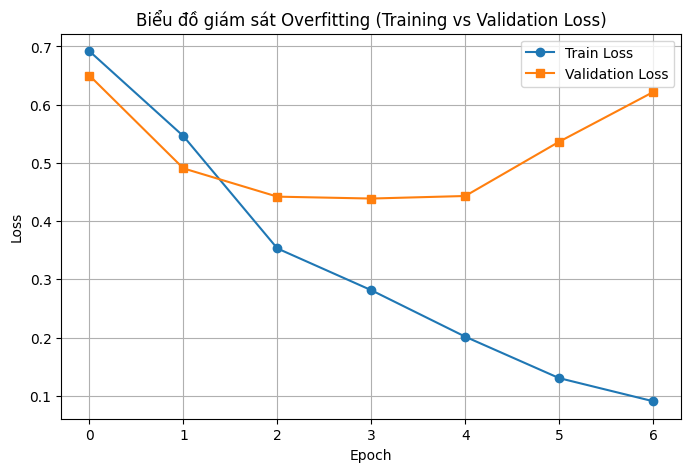


🏆 ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST (ĐỘC LẬP)
📌 Test Accuracy: 0.8675
📌 Test F1-Score (Macro): 0.8644
📌 Test Precision (Macro): 0.8692
📌 Test Recall (Macro): 0.8616

Chi tiết từng nhãn:
 - Nhãn 0 (Tiêu cực): Precision = 0.8780 | Recall = 0.8120 | F1 = 0.8438
 - Nhãn 1 (Tích cực): Precision = 0.8603 | Recall = 0.9112 | F1 = 0.8851


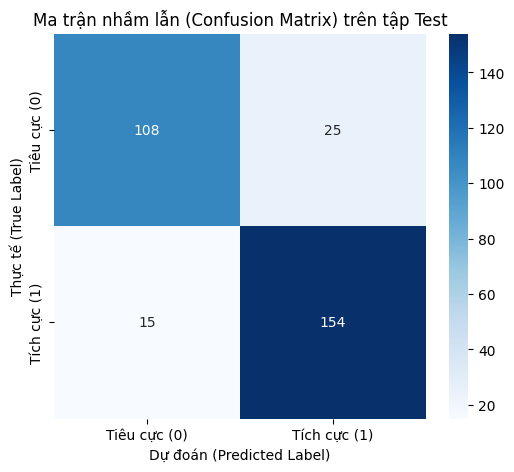

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. CẤU HÌNH & HẰNG SỐ (CONFIGURATIONS)
# ==========================================
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 2e-5 # Tốc độ học chuẩn cho Fine-tuning Transformer (nhỏ hơn training thông thường)
PATIENCE = 3 # Early stopping
MODEL_NAME = "vinai/phobert-base"

print("="*80)
print("🚀 KHỞI ĐỘNG FINE-TUNING PHO-BERT (BINARY CLASSIFICATION)")
print("="*80)

# ==========================================
# 2. XỬ LÝ DỮ LIỆU & CLASS WEIGHTS
# ==========================================
file_path = "/content/final_training_data_cleaned_v3.csv"
df = pd.read_csv(file_path)

df = df.dropna(subset=['cleaned_text', 'Label'])
df = df[df['Label'] != 2] # Chỉ giữ 0 và 1

X = df['cleaned_text'].astype(str).tolist()
y = df['Label'].astype(int).tolist()

# Chia 70% Train, 30% (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# Chia đôi phần 30% thành 15% Val và 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"📊 Tập Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# TÍNH TOÁN CLASS WEIGHTS ĐỂ XỬ LÝ MẤT CÂN BẰNG
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print(f"⚖️ Trọng số phạt cho hàm Loss (Class Weights): Tiêu cực (0) = {class_weights[0]:.4f}, Tích cực (1) = {class_weights[1]:.4f}")

# Dataset Class
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(label, dtype=torch.long)
        }

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_loader = DataLoader(SentimentDataset(X_train, y_train, tokenizer), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SentimentDataset(X_val, y_val, tokenizer), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(SentimentDataset(X_test, y_test, tokenizer), batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 3. MÔ HÌNH VÀ VÒNG LẶP HUẤN LUYỆN
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Đang sử dụng thiết bị: {device}")

# Sử dụng mô hình có sẵn lớp phân loại (Sequence Classification) của HuggingFace, num_labels=2
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model = model.to(device)

# Đưa Class Weights vào hàm Loss
loss_fn = nn.CrossEntropyLoss(
    weight=class_weights_tensor.to(device)
)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps*0.1), num_training_steps=total_steps)

# Các hàm đánh giá
def evaluate_model(model, dataloader):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            targets = batch['targets'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            loss = loss_fn(logits, targets)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(targets.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1_macro = precision_recall_fscore_support(all_targets, all_preds, average='macro', zero_division=0)[2]

    return avg_loss, f1_macro, all_targets, all_preds

# Huấn luyện
best_val_loss = float('inf')
epochs_no_improve = 0
history = {'train_loss': [], 'val_loss': []}

print("\nBắt đầu quá trình huấn luyện...")
for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}", leave=False)
    for batch in train_loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        targets = batch['targets'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, targets)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Tránh nổ gradient
        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    val_loss, val_f1, _, _ = evaluate_model(model, val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)

    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1-Macro: {val_f1:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_phobert_binary.pt')
        print("   -> Đã lưu mô hình tốt nhất!")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"🛑 Kích hoạt Early Stopping tại Epoch {epoch+1} (Val Loss không giảm trong {PATIENCE} epochs)")
            break

# ==========================================
# 4. VẼ BIỂU ĐỒ LOSS VÀ KIỂM TRA OVERFITTING
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', marker='s')
plt.title('Biểu đồ giám sát Overfitting (Training vs Validation Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 5. ĐÁNH GIÁ TRÊN TẬP TEST (MA TRẬN NHẦM LẪN)
# ==========================================
print("\n" + "="*80)
print("🏆 ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST (ĐỘC LẬP)")
print("="*80)

# Load lại mô hình tốt nhất
model.load_state_dict(torch.load('best_phobert_binary.pt'))
test_loss, test_f1, true_labels, pred_labels = evaluate_model(model, test_loader)

# Tính toán các chỉ số chi tiết
acc = accuracy_score(true_labels, pred_labels)
precision, recall, fscore, _ = precision_recall_fscore_support(true_labels, pred_labels, average=None)
precision_mac, recall_mac, fscore_mac, _ = precision_recall_fscore_support(true_labels, pred_labels, average='macro')

print(f"📌 Test Accuracy: {acc:.4f}")
print(f"📌 Test F1-Score (Macro): {fscore_mac:.4f}")
print(f"📌 Test Precision (Macro): {precision_mac:.4f}")
print(f"📌 Test Recall (Macro): {recall_mac:.4f}\n")

print(f"Chi tiết từng nhãn:")
print(f" - Nhãn 0 (Tiêu cực): Precision = {precision[0]:.4f} | Recall = {recall[0]:.4f} | F1 = {fscore[0]:.4f}")
print(f" - Nhãn 1 (Tích cực): Precision = {precision[1]:.4f} | Recall = {recall[1]:.4f} | F1 = {fscore[1]:.4f}")

# Vẽ Ma trận nhầm lẫn
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tiêu cực (0)', 'Tích cực (1)'], yticklabels=['Tiêu cực (0)', 'Tích cực (1)'])
plt.title('Ma trận nhầm lẫn (Confusion Matrix) trên tập Test')
plt.ylabel('Thực tế (True Label)')
plt.xlabel('Dự đoán (Predicted Label)')
plt.show()

In [2]:
!pip install bertopic umap-learn hdbscan sentence-transformers gensim scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.3 MB/s eta 0:00:00


In [ ]:
import json
import re
import pandas as pd
from vncorenlp import VnCoreNLP
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# CẤU HÌNH CƠ BẢN
# ==========================================
# Stop words
stop_words = {"và", "của", "là", "có", "trong", "cho", "những", "các", "một", "với",
              "để", "từ", "đến", "này", "khi", "như", "đã", "tại", "về", "nhận_ra"}

stop_words.update({
    "không", "được", "bị", "cùng", "phải", "sự", "việc", "trên", "dưới",
    "rất", "nhiều", "ít", "mình", "chúng", "ta", "bạn", "tôi",
    "này", "đó", "kia", "đây", "thì", "là", "đang", "đã", "sẽ",
    "vẫn", "cũng", "một_số", "mọi", "người", "lại", "vào", "nhưng", "hơn", "mà", "khiến", "liên"
})

vncorenlp = VnCoreNLP(
    "VnCoreNLP-master/VnCoreNLP-1.1.1.jar",
    annotators="wseg",
    max_heap_size='-Xmx2g'
)

def tokenize(text):
    sentences = vncorenlp.tokenize(text)
    tokens = []
    for sentence in sentences:
        tokens.extend(sentence)
    return " ".join(tokens)

# ================================
# HÀM CHECK 1 TỪ CÓ PHẢI TIẾNG VIỆT
# ================================
def is_vietnamese_word(word):
    # nếu có ít nhất 1 ký tự tiếng Việt có dấu thì giữ lại
    vietnamese_chars = "àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ"
    return any(ch in vietnamese_chars for ch in word)

# ================================
# TIỀN XỬ LÝ CHỈ GIỮ TIẾNG VIỆT
# ================================
def preprocess_vietnamese_post(text):
    if not text or not isinstance(text, str):
        return ""

    # bỏ phần EN Below hoặc phân cách
    text = text.split("----------------------")[0]
    text = re.sub(r'\[EN Below\]', '', text, flags=re.IGNORECASE)

    # xóa link
    text = re.sub(r'http\S+', ' ', text)

    # xóa hashtag #
    text = text.replace('#', ' ')

    # xóa số
    text = re.sub(r'\d+', ' ', text)

    # chuyển lowercase
    text = text.lower()

    # chỉ giữ ký tự tiếng Việt + chữ cái + khoảng trắng
    text = re.sub(r"[^a-zàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ\s]", " ", text)

    # chuẩn hóa khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenize bằng VnCoreNLP
    if not text:
        return ""

    tokenized_text = tokenize(text)
    words = tokenized_text.split()

    # chỉ giữ từ tiếng Việt có dấu hoặc chứa "đ"
    cleaned_words = [
        w for w in words
        if w not in stop_words
        and len(w) > 1
        and is_vietnamese_word(w)
    ]

    return " ".join(cleaned_words)

# ==========================================
# 3. QUÁ TRÌNH ĐỌC FILE VÀ XỬ LÝ HÀNG LOẠT
# ==========================================

# Chỉ định đường dẫn tới file JSON bài đăng của bạn
file_path = '/content/fb_post_test_final.json'

# Mở và đọc file JSON
with open(file_path, 'r', encoding='utf-8') as file:
    posts_data = json.load(file)

# Ép kiểu thành list nếu file JSON chỉ chứa 1 dict
if isinstance(posts_data, dict):
    posts_data = [posts_data]

processed_list = []

# Vòng lặp duyệt qua từng bài post
for post in posts_data:
    raw_text = post.get("text", "")

    # Đưa text vào hàm làm sạch
    cleaned_text = preprocess_vietnamese_post(raw_text)

    # Chỉ lưu lại những bài post có nội dung văn bản hợp lệ
    if cleaned_text:
        # 1. Bê nguyên toàn bộ dữ liệu từ JSON gốc
        processed_post = post.copy()

        # 2. Xử lý các trường ID tiềm năng để không bị lỗi hiển thị số khoa học trên Excel
        # Thay 'id', 'page_id' bằng tên trường ID thực tế trong file JSON của bạn nếu khác
        id_fields_to_fix = ['id', 'page_id', 'post_id']
        for field in id_fields_to_fix:
            if field in processed_post and processed_post[field]:
                processed_post[field] = f"\t{processed_post[field]}"

        # 3. Thêm cột mới
        processed_post["Cleaned_Text"] = cleaned_text

        processed_list.append(processed_post)

# 4. Chuyển kết quả thành DataFrame
df_posts = pd.DataFrame(processed_list)

# In ra 5 dòng đầu tiên để kiểm tra (điều chỉnh tên cột 'likes' cho khớp với file JSON của bạn)
if 'likes' in df_posts.columns:
    print(df_posts[['likes', 'Cleaned_Text']].head())
else:
    print(df_posts.head())

# Xuất kết quả ra file CSV
output_path = "/content/WildAct_Cleaned_Data_Posts_v2.csv"
df_posts.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"\n✅ Đã xử lý xong {len(df_posts)} bài viết hợp lệ và lưu vào file {output_path}!")
print("💡 Lưu ý: Các trường ID dài đã được thêm dấu tab (\\t) để Excel hiểu là định dạng Văn bản (Text).")

In [ ]:
import re
import pandas as pd
from vncorenlp import VnCoreNLP
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# CẤU HÌNH CƠ BẢN
# ==========================================

# Stop words
stop_words = {
    "và", "của", "là", "có", "trong", "cho", "những", "các", "một", "với",
    "để", "từ", "đến", "này", "khi", "như", "đã", "tại", "về", "nhận_ra"
}

stop_words.update({
    "không", "được", "bị", "cùng", "phải", "sự", "việc",
    "trên", "dưới", "rất", "nhiều", "ít",

    "mình", "chúng", "ta", "bạn", "tôi",
    "này", "đó", "kia", "đây",

    "thì", "là", "đang", "đã", "sẽ",
    "vẫn", "cũng", "mọi", "người",
    "lại", "vào", "nhưng", "hơn", "mà",

    "khiến", "liên"
})

# ==========================================
# LOAD VNCORENLP
# ==========================================

vncorenlp = VnCoreNLP(
    "VnCoreNLP-master/VnCoreNLP-1.1.1.jar",
    annotators="wseg",
    max_heap_size='-Xmx2g'
)

# ==========================================
# TOKENIZE
# ==========================================

def tokenize(text):

    sentences = vncorenlp.tokenize(text)

    tokens = []

    for sentence in sentences:
        tokens.extend(sentence)

    return " ".join(tokens)

# ==========================================
# CHECK TỪ TIẾNG VIỆT
# ==========================================

def is_vietnamese_word(word):

    vietnamese_chars = (
        "àáạảãâầấậẩẫăằắặẳẵ"
        "èéẹẻẽêềếệểễ"
        "ìíịỉĩ"
        "òóọỏõôồốộổỗơờớợởỡ"
        "ùúụủũưừứựửữ"
        "ỳýỵỷỹđ"
    )

    return any(ch in vietnamese_chars for ch in word)

# ==========================================
# PREPROCESS TEXT
# ==========================================

def preprocess_vietnamese_post(text):

    if not text or not isinstance(text, str):
        return ""

    # bỏ phần EN Below
    text = text.split("----------------------")[0]

    text = re.sub(
        r'\[EN Below\]',
        '',
        text,
        flags=re.IGNORECASE
    )

    # xóa link
    text = re.sub(r'http\S+', ' ', text)

    # xóa hashtag
    text = re.sub(r'#\S+', ' ', text)

    # xóa số
    text = re.sub(r'\d+', ' ', text)

    # lowercase
    text = text.lower()

    # chỉ giữ tiếng Việt + khoảng trắng
    text = re.sub(
        r"[^a-zàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩ"
        r"òóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ\s]",
        " ",
        text
    )

    # chuẩn hóa khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()

    if not text:
        return ""

    # tokenize
    tokenized_text = tokenize(text)

    words = tokenized_text.split()

    # lọc từ
    cleaned_words = [

        w for w in words

        if w not in stop_words
        and len(w) > 1
        and is_vietnamese_word(w)
    ]

    return " ".join(cleaned_words)

# ==========================================
# ĐỌC FILE CSV
# ==========================================

input_path = "/content/posts_found_in_comments.csv"

df = pd.read_csv(input_path)

print("Tổng số bài viết:", len(df))

# ==========================================
# XỬ LÝ TEXT
# ==========================================

df["Cleaned_Text"] = (

    df["text"]

    .fillna("")

    .astype(str)

    .apply(preprocess_vietnamese_post)
)

# ==========================================
# LOẠI BỎ POST RỖNG
# ==========================================

df = df[

    df["Cleaned_Text"]

    .str.strip()

    .ne("")
]

print("Số bài viết hợp lệ:", len(df))

# ==========================================
# FIX URL KHỎI BỊ EXCEL FORMAT
# ==========================================

if "url" in df.columns:

    df["url"] = (

        "\t" + df["url"].astype(str)
    )

# ==========================================
# XUẤT FILE CSV
# ==========================================

output_path = "/content/WildAct_Cleaned_Data_Posts_v2.csv"

df.to_csv(

    output_path,

    index=False,

    encoding="utf-8-sig"
)

print(f"\n✅ Đã lưu file: {output_path}")

# ==========================================
# XEM KẾT QUẢ
# ==========================================

print(
    df[
        [
            "text",
            "Cleaned_Text"
        ]
    ].head()
)

Tổng số bài viết: 379
Số bài viết hợp lệ: 378

✅ Đã lưu file: /content/WildAct_Cleaned_Data_Posts_v2.csv
                                                text  \
0  [ENG below] Mùa hè đến rồi nhưng liệu “khu du ...   
1  [ENG below] 160 học sinh cam kết đồng hành bảo...   
2  [ENG below] Nhiệt độ năm nay có lúc cao hơn từ...   
3  [ENG below] Mèo rừng - “Bảo vệ” thầm lặng của ...   
4  [ENG below] “Việc biết rằng mỗi kết nối mình t...   

                                        Cleaned_Text  
0  mùa hè rồi liệu du_lịch sinh_thái chuẩn_bị ghé...  
1  học_sinh cam_kết đồng_hành bảo_vệ di_cư hoạt_đ...  
2  nhiệt_độ năm lúc độ trước_đây năm hiếm_hoi thậ...  
3  mèo rừng bảo_vệ thầm_lặng núi_rừng tây_nguyên ...  
4  biết rằng mỗi kết_nối tạo đều có_thể trực_tiếp...  


In [ ]:
!pip install bertopic underthesea sentence-transformers pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.6 MB/s eta 0:00:00


In [ ]:
!pip install gensim umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd

# Đọc file CSV
df = pd.read_csv("/content/final_training_data_with_demographics_final.csv")

# Các cột cần kiểm tra
cols = ["location", "hometown", "birthday", "gender"]

# Đếm số lượng giá trị rỗng trên mỗi dòng
# isna(): NaN
# == '': chuỗi rỗng
empty_count = (
    df[cols].isna() |
    (df[cols].astype(str).apply(lambda x: x.str.strip() == ""))
).sum(axis=1)

# Giữ lại các comment có từ 3 trường rỗng trở lên
filtered_df = df[empty_count == 4]

# Xuất file mới
filtered_df.to_csv("/content/filtered_comments.csv", index=False, encoding="utf-8-sig")

print(f"Số lượng comment sau khi lọc: {len(filtered_df)}")

Số lượng comment sau khi lọc: 1529


In [ ]:
import pandas as pd
from underthesea import word_tokenize
import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# 1. Chuẩn bị dữ liệu mẫu
df = pd.read_csv("/content/WildAct_Cleaned_Data_Posts_v2 (1).csv")
docs = df['Cleaned_Text'].dropna().tolist()

# 2. Chuẩn bị danh sách Stopwords
custom_stopwords = [
    "và", "là", "của", "có", "để", "những", "cho", "trong", "một", "này", "với", "được", "các", "những", "từ", "ở", "về",
    "nhé", "nha", "ạ", "ơi", "luôn", "nữa", "đây", "đó", "kia", "thế", "nào",
    "click", "link", "chi_tiết", "inbox", "comment", "bài_viết", "post", "fanpage", "website", "chia_sẻ", "like",
    "mọi_người", "các_bạn", "anh_chị", "chúng_mình", "chúng_tôi", "mình", "bạn",
    "wildact", "wildact_vietnam", "tổ_chức", "phi_lợi_nhuận", "ngo"
]

# 3. Tiền xử lý: Tách từ & Lọc Stopwords cho Gensim
# Gensim yêu cầu đầu vào là một list các token (từ), thay vì một chuỗi text dài như CountVectorizer
def preprocess_text(text):
    # Tách từ bằng underthesea
    tokenized = word_tokenize(text, format="text")
    # Chuyển về chữ thường và tách thành list
    words = tokenized.lower().split()
    # Loại bỏ stopwords và các từ quá ngắn (dưới 2 ký tự)
    words = [w for w in words if w not in custom_stopwords and len(w) > 1]
    return words

# docs_tokenized bây giờ là list của list: [['hôm_nay', 'tổ_chức', ...], ['tê_giác', 'nguy_cơ', ...]]
docs_tokenized = [preprocess_text(doc) for doc in docs]

# 4. Tạo Dictionary và Corpus (tương đương với CountVectorizer)
id2word = corpora.Dictionary(docs_tokenized)

# filter_extremes tương đương với min_df=2 và max_df=0.9 trong CountVectorizer
id2word.filter_extremes(no_below=2, no_above=0.9)

corpus = [id2word.doc2bow(text) for text in docs_tokenized]

# 5. Huấn luyện mô hình LDA
# LƯU Ý: Khác với BERTopic, LDA yêu cầu bạn phải khai báo trước số lượng Topic
NUM_TOPICS = 13

lda_model = LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=NUM_TOPICS,
    random_state=42,
    update_every=1,
    chunksize=100,
    passes=10,        # Số epoch đi qua corpus (tăng lên nếu data phức tạp)
    alpha='auto',     # Tự động tối ưu hóa phân bố topic trên văn bản
    per_word_topics=True
)

# 6. Tính toán số lượng bình luận cho mỗi Topic (Dominant Topic)
# Vì LDA trả về xác suất đa chủ đề cho 1 văn bản, ta sẽ xếp văn bản vào chủ đề có xác suất cao nhất
topic_counts = {i: 0 for i in range(NUM_TOPICS)}

for row in corpus:
    # Lấy phân bố xác suất chủ đề cho văn bản hiện tại
    topic_probs = lda_model.get_document_topics(row)
    if topic_probs:
        # Tìm topic có xác suất lớn nhất
        dominant_topic = max(topic_probs, key=lambda x: x[1])[0]
        topic_counts[dominant_topic] += 1

# ==========================================
# 7. IN KẾT QUẢ TOPIC MODELING (ĐỊNH DẠNG CHUẨN)
# ==========================================
print("\n--- KẾT QUẢ TOPIC MODELING (LDA) ---\n")

# Lấy top 10 từ khóa cho mỗi topic
topics = lda_model.show_topics(num_topics=NUM_TOPICS, num_words=10, formatted=False)

for topic_id, words_probs in topics:
    count = topic_counts.get(topic_id, 0)

    # Chỉ lấy từ khóa, bỏ qua xác suất
    words = [word for word, prob in words_probs]
    words_str = ", ".join(words)

    print(f"[Topic {topic_id}] (Số lượng: {count} bình luận)")
    print(f"➜ 10 từ khóa: {words_str}\n")


# ==========================================
# 8. TÍNH TOÁN CHỈ SỐ COHERENCE (C_v)
# ==========================================
print("Đang tính toán chỉ số C_v Coherence...")

coherence_model_lda = CoherenceModel(
    model=lda_model,
    texts=docs_tokenized,
    dictionary=id2word,
    coherence='c_v'
)

coherence_cv = coherence_model_lda.get_coherence()
print(f"Chỉ số Topic Coherence (C_v): {coherence_cv:.4f}")


--- KẾT QUẢ TOPIC MODELING (LDA) ---

[Topic 0] (Số lượng: 133 bình luận)
➜ 10 từ khóa: rừng, chư, bảo_vệ, tuần_tra, kiểm_lâm, bẫy, cộng_đồng, đội, giữ, ngày

[Topic 1] (Số lượng: 8 bình luận)
➜ 10 từ khóa: làm_việc, phụ_nữ, ứng_tuyển, ứng_viên, vị_trí, vui_lòng, đề_tài, cơ_hội, ngành, bài

[Topic 2] (Số lượng: 19 bình luận)
➜ 10 từ khóa: loài, việt_nam, sư_tử, mỏ, thìa, khác, sống, có_thể, cách, nuôi

[Topic 3] (Số lượng: 8 bình luận)
➜ 10 từ khóa: động_vật, loài, cá_thể, tê_tê, vườn_quốc_gia, quý_hiếm, tự_nhiên, mặt, thịt, nguy_cấp

[Topic 4] (Số lượng: 1 bình luận)
➜ 10 từ khóa: tết, môi_trường, trái_đất, dụng_cụ, nhựa, hành_động, đừng, hãy, rác, rác_thải

[Topic 5] (Số lượng: 0 bình luận)
➜ 10 từ khóa: trồng, phù_hợp, đồ_ăn, thức_ăn, ăn, đấy, đồ, hại, đau_lòng, tính_toán

[Topic 6] (Số lượng: 0 bình luận)
➜ 10 từ khóa: quan_niệm, nấu_nướng, nghĩa, kỳ_vọng, mặc_định, thường_trực, bát, kính, thể_chất, áp_đặt

[Topic 7] (Số lượng: 0 bình luận)
➜ 10 từ khóa: thương_hiệu, cao_cấp, ngăn

In [8]:
!apt-get update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,646 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,070 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntug

In [7]:
!pip install vncorenlp

In [9]:
!wget https://github.com/vncorenlp/VnCoreNLP/archive/refs/heads/master.zip
!unzip master.zip

--2026-05-22 15:19:37--  https://github.com/vncorenlp/VnCoreNLP/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/vncorenlp/VnCoreNLP/zip/refs/heads/master [following]
--2026-05-22 15:19:37--  https://codeload.github.com/vncorenlp/VnCoreNLP/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.112.10
Connecting to codeload.github.com (codeload.github.com)|140.82.112.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [            <=>     ] 160.84M  11.5MB/s    in 11s     

2026-05-22 15:19:49 (14.6 MB/s) - ‘master.zip’ saved [168648997]

Archive:  master.zip
62bbc58fe5d113c898eae112656be97dcf50b3a0
   creating: VnCoreNLP-master/
  inflating: VnCoreNLP-master/LICENSE.md 

📊 Gender distribution (unique commenters):

Khác: 76.90%
Nam: 12.88%
Nữ: 10.21%


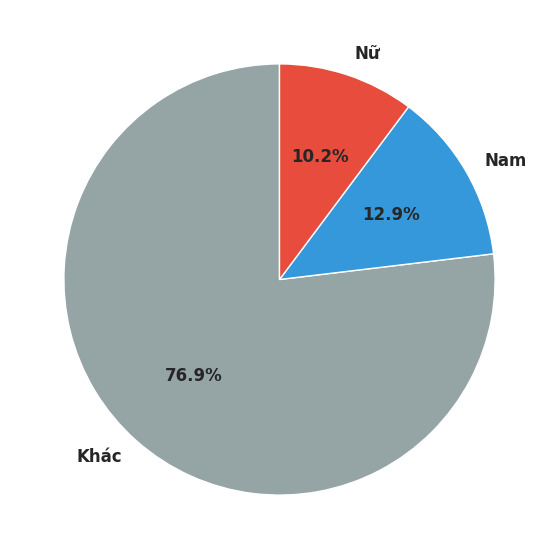

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. LOAD DATA
# =========================
file_path = "/content/comments_with_posts.csv"
df = pd.read_csv(file_path)

# =========================
# 2. KEEP UNIQUE USERS
# =========================
# Thêm .copy() để tránh cảnh báo SettingWithCopyWarning của Pandas
df_unique = df.drop_duplicates(subset=["profileId"]).copy()

# =========================
# 3. CLEAN GENDER
# =========================
def normalize_gender(g):
    if pd.isna(g):
        return "Khác"

    g = str(g).strip().lower()

    if g in ["male", "m", "nam", "man", "male "]:
        return "Nam"
    elif g in ["female", "f", "nu", "nữ", "woman", "female "]:
        return "Nữ"
    else:
        return "Khác"

df_unique["gender_norm"] = df_unique["gender"].apply(normalize_gender)

# =========================
# 4. COUNT + PERCENTAGE
# =========================
gender_counts = df_unique["gender_norm"].value_counts()

total = gender_counts.sum()
gender_percent = (gender_counts / total) * 100

print("📊 Gender distribution (unique commenters):\n")
for k, v in gender_percent.items():
    print(f"{k}: {v:.2f}%")

# =========================
# 5. PIE CHART
# =========================
# Định nghĩa bộ màu đồng nhất với biểu đồ trước
color_map = {
    'Nam': '#3498db',  # Xanh dương
    'Nữ': '#e74c3c',   # Đỏ hồng
    'Khác': '#95a5a6'  # Xám
}

# Lấy ra danh sách màu khớp với thứ tự của gender_counts.index
pie_colors = [color_map[label] for label in gender_counts.index]

plt.figure(figsize=(7, 7))

# Vẽ biểu đồ tròn
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    colors=pie_colors,                 # Áp dụng bộ màu đã setup
    startangle=90,                     # Xoay biểu đồ 90 độ để góc nhìn cân đối hơn
    wedgeprops={'edgecolor': 'white'}, # Thêm viền trắng giữa các mảnh cắt
    textprops={'fontsize': 12, 'fontweight': 'bold'} # Làm chữ to và in đậm
)

#plt.title("Tỷ lệ Giới tính người bình luận (Unique)", fontsize=14, fontweight='bold', pad=20)
plt.show()

/tmp/ipykernel_1733/1907337611.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["date"].dt.to_period("M")
/tmp/ipykernel_1733/1907337611.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique["gender_norm"] = df_unique["gender"].apply(normalize_gender)


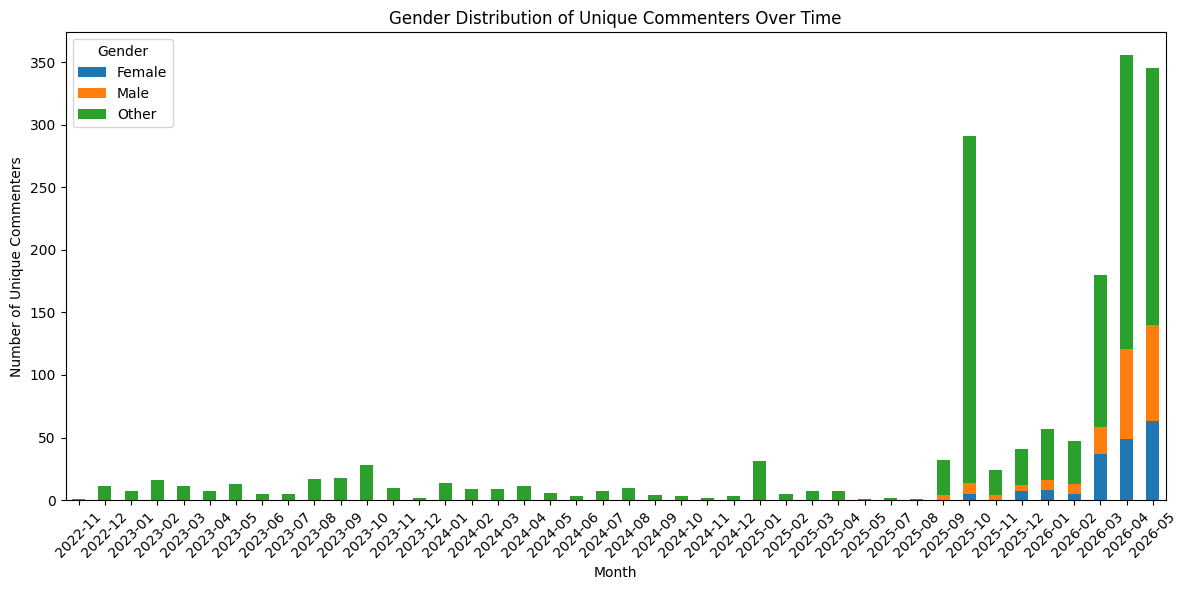

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/final_training_data_with_demographics_final.csv")

# convert date
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# tạo tháng
df["month"] = df["date"].dt.to_period("M")


df_unique = df.drop_duplicates(subset=["profileId"])

# normalize gender
def normalize_gender(g):
    if pd.isna(g):
        return "Other"
    g = str(g).strip().lower()
    if g in ["male", "m", "nam", "man"]:
        return "Male"
    elif g in ["female", "f", "nu", "nữ", "woman"]:
        return "Female"
    else:
        return "Other"

df_unique["gender_norm"] = df_unique["gender"].apply(normalize_gender)

gender_month = df_unique.groupby(["month", "gender_norm"]).size().unstack(fill_value=0)

gender_month.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Gender Distribution of Unique Commenters Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Unique Commenters")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

In [5]:
!pip install pandas regex emoji underthesea vncorenlp unidecode

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 15.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.9 MB/s eta 0:00:00
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=dcba12f786aafa3e07d9956b7c122a94b5fff2a7e0003623737b5cf440281afd
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp


In [12]:
# ==========================================
# TIỀN XỬ LÝ BÌNH LUẬN TIẾNG VIỆT
# Dành cho:
# - Sentiment Analysis
# - Topic Modeling
# - Dữ liệu Facebook từ WildAct
# ==========================================

# CÀI THƯ VIỆN (chạy 1 lần)


import pandas as pd
import re
import regex
import emoji
from unidecode import unidecode
from vncorenlp import VnCoreNLP
# ==========================================
# 1. ĐỌC FILE CSV
# ==========================================

input_file = "/content/final_training_data_with_demographics_final.csv"       # đổi thành tên file của bạn
output_file = "/content/final_training_data_with_demographics_final_v2.csv"

df = pd.read_csv(input_file)

# ==========================================
# 2. STOPWORDS
# ==========================================

custom_stopwords = {

    # filler words
    "ạ", "à", "ừ", "ờ",
    "nha", "nhé", "nhe",
    "hehe", "haha", "hihi",
    "kkk", "kkkk",

    # social media words
    "ad", "admin", "page",
    "ib", "inbox",

    # common meaningless words
    "đó", "này", "kia",
    "vậy", "thôi",
    "luôn", "rồi",

    # pronouns
    "mình", "tui", "tao",
    "tớ", "mọi", "người",
    "các", "những"
}

# ==========================================
# 3. LOAD TEENCODE DICTIONARY
# KẾT HỢP:
# - file teencode.txt
# - custom teencode bổ sung
# ==========================================

# File teencode.txt có format:
# ctrai    con trai
# khôg     không
# ...

teencode_file = "/content/teencode.txt"

# dictionary mặc định bổ sung thêm
extra_teencode_dict = {

    # phủ định
    "ko": "không",
    "kh": "không",
    "k": "không",
    "hok": "không",
    "hem": "không",
    "hông": "không",

    # phổ biến
    "dc": "được",
    "đc": "được",

    "j": "gì",

    "mik": "mình",
    "mk": "mình",

    "bn": "bạn",

    "cx": "cũng",
    "vs": "với",

    "thik": "thích",
    "iu": "yêu",

    "mn": "mọi người",

    # không dấu
    "dep": "đẹp",
    "tot": "tốt",
    "xau": "xấu",
    "hay": "hay",

    "yeu": "yêu",
    "thuong": "thương",

    "camon": "cảm ơn",
    "dangyeu": "đáng yêu",
    "tuyetvoi": "tuyệt vời",

    # domain
    "dongvat": "động vật",
    "wildlife": "động vật hoang dã",
    "rung": "rừng",
    "baove": "bảo vệ",
    "thiennhien": "thiên nhiên",
    "moitruong": "môi trường"
}

# ==========================================
# LOAD FILE teencode.txt
# ==========================================

normalize_dict = {}

with open(teencode_file, "r", encoding="utf-8") as f:

    for line in f:

        line = line.strip()

        if not line:
            continue

        parts = line.split("\t")

        # đảm bảo đúng format
        if len(parts) >= 2:

            slang = parts[0].strip().lower()
            meaning = parts[1].strip().lower()

            normalize_dict[slang] = meaning

# merge với dictionary bổ sung
normalize_dict.update(extra_teencode_dict)

print(f"Số lượng teencode loaded: {len(normalize_dict)}")

# ==========================================
# 4. VIETNAMESE CHARACTER SET
# ==========================================

vietnamese_chars = set(
    "àáạảãâầấậẩẫăằắặẳẵ"
    "èéẹẻẽêềếệểễ"
    "ìíịỉĩ"
    "òóọỏõôồốộổỗơờớợởỡ"
    "ùúụủũưừứựửữ"
    "ỳýỵỷỹ"
    "đ"
)

# ==========================================
# 5. EMOJI -> TEXT
# Chỉ giữ emoji có trong emoji_dict
# Emoji khác sẽ bị xóa
# ==========================================

emoji_dict = {

    ":red_heart:": " yêu ",
    ":smiling_face_with_heart-eyes:": " thích ",
    ":thumbs_up:": " thích ",
    ":clapping_hands:": " hoan_nghênh ",

    ":crying_face:": " buồn ",
    ":loudly_crying_face:": " rất_buồn ",
    ":angry_face:": " tức_giận ",

    ":fire:": " tuyệt_vời ",
    ":smiling_face:": " vui ",
    ":face_with_tears_of_joy:": " vui "
}

def convert_emoji(text):

    # chuyển emoji -> :emoji_name:
    text = emoji.demojize(text, language='en')

    # regex tìm tất cả emoji dạng :xxx:
    emoji_patterns = re.findall(r':[a-zA-Z0-9_\-&]+:', text)

    for emj in emoji_patterns:

        # nếu có trong dictionary -> thay bằng text
        if emj in emoji_dict:
            text = text.replace(emj, emoji_dict[emj])

        # nếu không có -> xóa luôn
        else:
            text = text.replace(emj, ' ')

    return text
# ==========================================
# 6. REMOVE URL
# ==========================================

def remove_url(text):

    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'www\S+', ' ', text)

    return text

# ==========================================
# 7. NORMALIZE REPEATED CHARACTERS
# hayyyyyyy -> hay
# ==========================================

def normalize_repeated_chars(text):

    text = re.sub(r'(.)\1{2,}', r'\1', text)

    return text

# ==========================================
# 8. TEENCODE NORMALIZATION
# ==========================================

def normalize_teencode(text):

    words = text.split()

    normalized_words = []

    for word in words:

        if word in normalize_dict:
            normalized_words.append(normalize_dict[word])
        else:
            normalized_words.append(word)

    return " ".join(normalized_words)

# ==========================================
# 9. REMOVE SPECIAL CHARACTERS
# ==========================================

def remove_special_characters(text):

    text = regex.sub(r'[^\p{L}\p{N}\s_]', ' ', text)

    return text

# ==========================================
# 10. REMOVE EXTRA SPACES
# ==========================================

def remove_extra_spaces(text):

    return re.sub(r'\s+', ' ', text).strip()

# ==========================================
# 11. REMOVE STOPWORDS
# ==========================================

def remove_stopwords(text):

    words = text.split()

    filtered_words = [
        w for w in words
        if w not in custom_stopwords
    ]

    return " ".join(filtered_words)

# ==========================================
# 12. KIỂM TRA TIẾNG VIỆT
# ==========================================

def is_vietnamese(text):
    """Chỉ lấy câu có tỷ lệ chữ có dấu > 10%"""

    if pd.isna(text):
        return False

    text = str(text).lower()

    vn_count = sum(c in vietnamese_chars for c in text)

    letter_count = sum(c.isalpha() for c in text)

    if letter_count == 0:
        return False

    return (vn_count / letter_count) > 0.1

# ==========================================
# 13. VNCoreNLP WORD SEGMENTATION
# ==========================================

vncorenlp = VnCoreNLP(
    "VnCoreNLP-master/VnCoreNLP-1.1.1.jar",
    annotators="wseg",
    max_heap_size='-Xmx2g'
)

def tokenize(text):

    try:

        sentences = vncorenlp.tokenize(text)

        tokens = []

        for sentence in sentences:
            tokens.extend(sentence)

        return " ".join(tokens)

    except:
        return text

# ==========================================
# 14. HÀM CLEAN CHÍNH
# ==========================================

def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # emoji -> text
    text = convert_emoji(text)

    # remove url
    text = remove_url(text)

    # normalize repeated chars
    text = normalize_repeated_chars(text)

    # normalize teencode
    text = normalize_teencode(text)

    # remove special chars
    text = remove_special_characters(text)

    # remove extra spaces
    text = remove_extra_spaces(text)

    # remove stopwords
    text = remove_stopwords(text)

    # tokenize
    text = tokenize(text)

    # remove spaces again
    text = remove_extra_spaces(text)

    return text

# ==========================================
# 15. CHỈ GIỮ COMMENT TIẾNG VIỆT
# ==========================================

print("Đang lọc comment tiếng Việt...")

df = df[df["text"].astype(str).apply(is_vietnamese)]

# ==========================================
# 16. TẠO cleaned_text
# ==========================================

print("Đang tiền xử lý dữ liệu...")

df["cleaned_text"] = df["text"].astype(str).apply(clean_text)

# ==========================================
# 17. XÓA DÒNG RỖNG
# ==========================================

df = df[df["cleaned_text"].str.strip() != ""]

# ==========================================
# 18. EXPORT FILE
# ==========================================

df.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("Hoàn thành!")
print(f"Saved to: {output_file}")

# ==========================================
# 19. PREVIEW
# ==========================================

print(df[["text", "cleaned_text"]].head(20))

Số lượng teencode loaded: 406
Đang lọc comment tiếng Việt...
Đang tiền xử lý dữ liệu...
Hoàn thành!
Saved to: /content/final_training_data_with_demographics_final_v2.csv
                                                 text  \
0   Mình cũng là một "thợ săn chim" vũ khí của mìn...   
1   Tôi dân Quảng Ninh vừa có biển vừa có rừng mà ...   
2   Nhiều người vẫn nghĩ “không nằm trong danh sác...   
3   Mỗi loại đều có vẻ đẹp riêng , có loài này để ...   
4   ao tôm bị chim biển vào lây bệnh, giăng lưới c...   
5   lúc Admin ăn cơm sườn nè he , gà kho gừng , cu...   
6   Qua các bài đánh giá GG, mình thấy họ chỉ xem ...   
7   t đã từng cho con vào sở thú TTTM như post 1 l...   
8   Từ khi đọc qua cuốn sách Vẻ đẹp của cảnh sắc t...   
9   mún động vật thì chịu khó dẫn đi zoo dùm đi, v...   
10  Người lớn thật ra cũng không "lớn" mấy nhỉ, bả...   
11  Người viết bài này chắc chưa bao h biết ăn thị...   
12  Không hiểu sao đến giờ vẫn có người coi đây là...   
13  Mọi người tốt nhất cùng mình

In [13]:
import pandas as pd
import re

print("⏳ Đọc dữ liệu...")
comments = pd.read_csv("/content/comments_with_posts.csv")
posts = pd.read_csv("/content/WildAct_Assigned_Topics_v2.csv")

# ==========================================
# 1. HÀM CẮT LẤY ID SAU CHỮ "posts/"
# ==========================================
def get_post_id(url):
    if pd.isna(url):
        return None
    url = str(url)

    # Lệnh regex này tìm đúng chữ "posts/"
    # và lấy ra chuỗi ký tự liền sau đó cho đến khi gặp dấu "/" hoặc "?"
    match = re.search(r'posts/([^/?]+)', url)

    if match:
        return match.group(1) # Trả về đúng đoạn mã ID
    return None

print("🔍 Đang trích xuất ID từ URL...")
# Tạo cột khóa phụ 'join_id' cho cả 2 bảng
comments['join_id'] = comments['inputUrl'].apply(get_post_id)
posts['join_id'] = posts['url'].apply(get_post_id)

# In thử 3 dòng ra màn hình để bạn dễ dàng debug (kiểm tra bằng mắt)
print("\n--- CHECK 3 ID TỪ FILE COMMENTS ---")
print(comments[['inputUrl', 'join_id']].dropna(subset=['join_id']).head(3))

print("\n--- CHECK 3 ID TỪ FILE POSTS ---")
print(posts[['url', 'join_id']].dropna(subset=['join_id']).head(3))

# ==========================================
# 2. TIẾN HÀNH GHÉP NỐI
# ==========================================
print("\n⏳ Đang tiến hành ghép nối dữ liệu...")

# Ghép 2 bảng thông qua cái mã ID vừa cắt được
df = comments.merge(
    posts,
    on="join_id",           # Sử dụng cột ID mới cắt làm khóa
    how="left",             # Giữ nguyên toàn bộ comment
    suffixes=("", "_post")
)

# ==========================================
# 3. DỌN DẸP DỮ LIỆU & LƯU FILE
# ==========================================
# Xóa cột url và cột join_id tạm thời vì không cần nữa
cols_to_drop = [col for col in ['url', 'join_id'] if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

# Xóa các cột bị trùng lặp mang đuôi '_post'
duplicate_cols = [col for col in df.columns if col.endswith('_post')]
df.drop(columns=duplicate_cols, inplace=True)

# KIỂM TRA TỶ LỆ THÀNH CÔNG
success_count = df['Topic_ID'].notna().sum()
total_count = len(df)
print(f"\n✅ KẾT QUẢ MERGE: {success_count} / {total_count} comment đã lấy được Topic_ID thành công!")

# Lưu kết quả
output_path = "/content/comments_with_posts_v2.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"Đã lưu file dữ liệu hoàn chỉnh tại: {output_path}")

⏳ Đọc dữ liệu...
🔍 Đang trích xuất ID từ URL...

--- CHECK 3 ID TỪ FILE COMMENTS ---
                                            inputUrl  \
0  https://www.facebook.com/WildActvn/posts/pfbid...   
1  https://www.facebook.com/WildActvn/posts/pfbid...   
2  https://www.facebook.com/WildActvn/posts/pfbid...   

                                             join_id  
0  pfbid02NY9fsBTJm3RHa9gU9LEfTjePAZN1y6xGGZJKNV6...  
1  pfbid02NY9fsBTJm3RHa9gU9LEfTjePAZN1y6xGGZJKNV6...  
2  pfbid02NY9fsBTJm3RHa9gU9LEfTjePAZN1y6xGGZJKNV6...  

--- CHECK 3 ID TỪ FILE POSTS ---
                                                 url  \
0  \thttps://www.facebook.com/WildActvn/posts/pfb...   
1  \thttps://www.facebook.com/WildActvn/posts/pfb...   
2  \thttps://www.facebook.com/WildActvn/posts/pfb...   

                                             join_id  
0  pfbid0EcV97Ng4gkVaA1MsuMbCx1ptZMsGL1QsDdVqmvBo...  
1  pfbid02iZ455YHbKyQsZym4xHw4jhPhcdTVRjDLb66EN6s...  
2  pfbid03chVXo2F1Eg2XqCznQWvsum7hgDnjMm74zE55

/tmp/ipykernel_1733/782398576.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['Thang_Nam'] = df['date'].dt.to_period('M').astype(str)


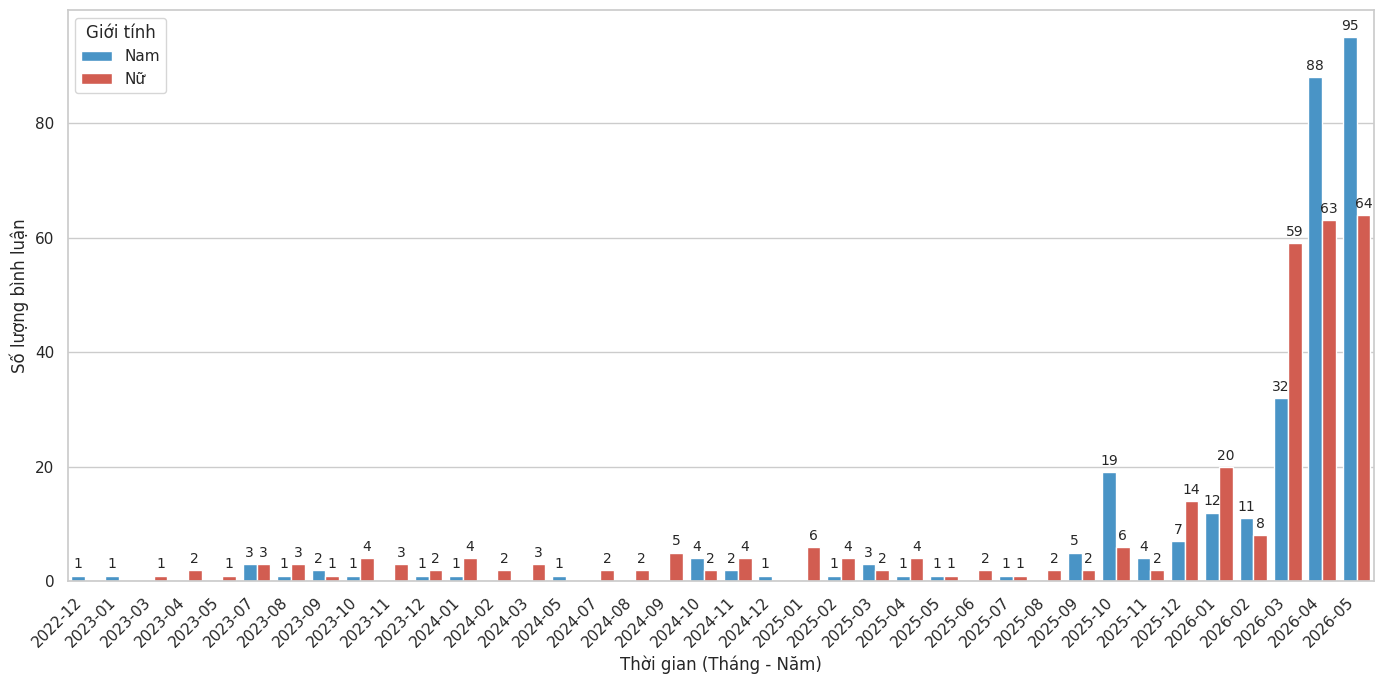

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")

# 1. Đọc dữ liệu (Nhớ thay đường dẫn file thực tế)
df = pd.read_csv("/content/comments_with_posts.csv")

# 2. Xử lý thời gian (Lấy định dạng Năm-Tháng)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['Thang_Nam'] = df['date'].dt.to_period('M').astype(str)

# Lọc bỏ các dòng không có ngày tháng hợp lệ
df = df[df['Thang_Nam'] != 'NaT']

# 3. Lọc dữ liệu Giới tính
gender_col = 'gender'

# CHỈ lấy các dòng có giá trị chính xác là 'Nam' hoặc 'Nữ' (bỏ qua 'Khác' hoặc rỗng)
df_gender = df[df[gender_col].isin(['Nam', 'Nữ'])].copy()

# 4. Thống kê số lượng theo Tháng và Giới tính
# Cột 'Count' sẽ chứa số lượng bình luận
monthly_gender_counts = df_gender.groupby(['Thang_Nam', gender_col]).size().reset_index(name='Count')

# Sắp xếp lại theo thời gian để biểu đồ xuôi theo trục tháng
monthly_gender_counts = monthly_gender_counts.sort_values('Thang_Nam')

# 5. Vẽ biểu đồ
plt.figure(figsize=(14, 7))

# Sử dụng palette để gán màu cụ thể (VD: Nam màu xanh, Nữ màu đỏ hồng)
my_colors = {'Nam': '#3498db', 'Nữ': '#e74c3c'}

ax = sns.barplot(
    data=monthly_gender_counts,
    x='Thang_Nam',
    y='Count',
    hue=gender_col,
    palette=my_colors
)

# Cấu hình tiêu đề và nhãn
#plt.title("Số lượng bình luận của Nam và Nữ theo từng tháng", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Thời gian (Tháng - Năm)", fontsize=12)
plt.ylabel("Số lượng bình luận", fontsize=12)
plt.xticks(rotation=45, ha='right') # Xoay nhãn trục X để không bị đè lên nhau
plt.legend(title="Giới tính", fontsize=11, title_fontsize=12)

# Gắn nhãn số liệu trực tiếp lên đầu mỗi cột
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

In [27]:
import pandas as pd
import plotly.express as px
import requests
import re
import unicodedata
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. ĐỌC DỮ LIỆU
# ==========================================
file_path = "/content/comments_with_posts.csv"
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print("⚠️ Không tìm thấy file CSV, vui lòng kiểm tra lại đường dẫn!")

# ==========================================
# BIỂU ĐỒ 1: BIỂU ĐỒ TRÒN % NAM NỮ (HÌNH VUÔNG CỐ ĐỊNH)
# ==========================================
print("⏳ Đang vẽ Biểu đồ 1: Tỷ lệ Giới tính...")

# Chỉ lấy 1 bình luận đại diện cho 1 người để tỷ lệ giới tính không bị nhiễu
df_unique_users = df.drop_duplicates(subset=['profileId']).copy()

df_gender = df_unique_users.dropna(subset=['gender']).copy()
df_gender = df_gender[df_gender['gender'].str.lower().isin(['nam', 'nữ', 'male', 'female'])]
df_gender['gender'] = df_gender['gender'].str.capitalize().replace({'Male': 'Nam', 'Female': 'Nữ'})

gender_counts = df_gender['gender'].value_counts().reset_index()
gender_counts.columns = ['Giới tính', 'Số lượng']

fig1 = px.pie(
    gender_counts,
    values='Số lượng',
    names='Giới tính',
  # title='Tỷ lệ Nam/Nữ tham gia bình luận (Unique Users)',
    color='Giới tính',
    color_discrete_map={'Nam': '#3498db', 'Nữ': '#e74c3c'},
    hole=0.4
)
fig1.update_traces(textposition='inside', textinfo='percent+label')

# CỐ ĐỊNH HÌNH VUÔNG 600x600
fig1.update_layout(
    width=600,
    height=600,
    autosize=False
)
fig1.show()

# ==========================================
# BIỂU ĐỒ 2: BIỂU ĐỒ CỘT THEO THÁNG & GIỚI TÍNH (CỐ ĐỊNH KÍCH THƯỚC)
# ==========================================
print("⏳ Đang vẽ Biểu đồ 2: Độ Hot của bài post theo tháng và giới tính...")

# Sử dụng dataframe ban đầu (tính trên toàn bộ bình luận)
df_hotness = df.dropna(subset=['gender']).copy()
df_hotness = df_hotness[df_hotness['gender'].str.lower().isin(['nam', 'nữ', 'male', 'female'])]
df_hotness['gender'] = df_hotness['gender'].str.capitalize().replace({'Male': 'Nam', 'Female': 'Nữ'})

df_hotness['date'] = pd.to_datetime(df_hotness['date'], errors='coerce')
df_hotness['Month_Year'] = df_hotness['date'].dt.strftime('%Y-%m')

# Cập nhật tên cột chuẩn xác theo file CSV
for col in ['likes', 'comments_post', 'shares']:
    df_hotness[col] = pd.to_numeric(df_hotness[col], errors='coerce').fillna(0)

df_hotness['Hotness'] = df_hotness['likes'] + df_hotness['comments_post'] + df_hotness['shares']

df_hotness_grouped = df_hotness.groupby(['Month_Year', 'gender'])['Hotness'].sum().reset_index()

fig2 = px.bar(
    df_hotness_grouped,
    x='Month_Year',
    y='Hotness',
    color='gender',
    title='Độ Hot của bài post theo Tháng (Phân loại theo Giới tính)',
    labels={'Month_Year': 'Tháng', 'Hotness': 'Tổng Tương Tác (Độ Hot)', 'gender': 'Giới tính'},
    color_discrete_map={'Nam': '#3498db', 'Nữ': '#e74c3c'},
    barmode='stack'
)

# CỐ ĐỊNH HÌNH VUÔNG 700x700
fig2.update_layout(
    width=700,
    height=700,
    autosize=False,
    xaxis_tickangle=-45
)
fig2.show()

# ==========================================
# BIỂU ĐỒ 3: BẢN ĐỒ VỊ TRÍ (HIỆN TỔNG SỐ BÌNH LUẬN)
# ==========================================
print("⏳ Đang vẽ Biểu đồ 3: Bản đồ Phân bổ Vị trí Địa lý...")

url_geojson = "https://data.opendevelopmentmekong.net/dataset/999c96d8-fae0-4b82-9a2b-e481f6f50e12/resource/2818c2c5-e9c3-440b-a9b8-3029d7298065/download/diaphantinhenglish.geojson"
response = requests.get(url_geojson)
vn_geojson = response.json()

all_provinces = [feature['properties']['Name'] for feature in vn_geojson['features']]
df_all = pd.DataFrame({'GeoJSON_Name': all_provinces})

def remove_accents(input_str):
    if pd.isna(input_str):
        return ""
    s1 = unicodedata.normalize('NFKD', str(input_str)).encode('ASCII', 'ignore').decode('utf-8')
    s1 = re.sub(r'[đĐ]', 'd', s1)
    return s1.lower().strip()

df_all['Normalized_Name'] = df_all['GeoJSON_Name'].apply(remove_accents)

def extract_province_from_string(raw_text, province_list):
    loc_clean = remove_accents(raw_text)
    if not loc_clean: return None

    # TỪ ĐIỂN MAPPING
    mapping_dict = {
        'ha noi': 'ha noi', 'hn': 'ha noi',
        'hai phong': 'hai phong', 'gia phong': 'hai phong', 'cat ba': 'hai phong',
        'quang ninh': 'quang ninh', 'ha long': 'quang ninh', 'binh lieu': 'quang ninh', 'hai ha': 'quang ninh',
        'phu tho': 'phu tho', 'viet tri': 'phu tho',
        'bac giang': 'bac giang',
        'hai duong': 'hai duong',
        'thai nguyen': 'thai nguyen',
        'thai binh': 'thai binh',
        'nam dinh': 'nam dinh',
        'ninh binh': 'ninh binh', 'phat diem': 'ninh binh',
        'ha nam': 'ha nam',
        'hung yen': 'hung yen',
        'hoa binh': 'hoa binh',
        'son la': 'son la',
        'dien bien phu': 'dien bien',
        'lao cai': 'lao cai', 'bao thang': 'lao cai', 'hoang lien son': 'lao cai',
        'yen bai': 'yen bai',
        'lang son': 'lang son',
        'tuyen quang': 'tuyen quang',
        'ha giang': 'ha giang',
        'hoa loan': 'vinh phuc', 'vinh phu': 'vinh phuc',
        'thanh hoa': 'thanh hoa',
        'nghe an': 'nghe an', 'vinh': 'nghe an', 'quynh luu': 'nghe an', 'nghi loc': 'nghe an', 'thanh chuong': 'nghe an', 'con cuong': 'nghe an', 'cho do luong': 'nghe an', 'thai hoa': 'nghe an',
        'quang binh': 'quang binh', 'tuyen hoa': 'quang binh', 'dong hoi': 'quang binh', 'le thuy': 'quang binh',
        'hue': 'thua thien hue', 'thua thien': 'thua thien hue', 'bach ma': 'thua thien hue', 'a luoi': 'thua thien hue', 'binh tri thien': 'thua thien hue',
        'da nang': 'da nang', 'hai chau': 'da nang',
        'quang nam': 'quang nam',
        'quang ngai': 'quang ngai',
        'binh dinh': 'binh dinh', 'hoai nhon': 'binh dinh', 'phu phong': 'binh dinh', 'hoai an': 'binh dinh',
        'phu yen': 'phu yen', 'dong hoa': 'phu yen', 'la hai': 'phu yen', 'phu khanh': 'phu yen',
        'khanh hoa': 'khanh hoa', 'nha trang': 'khanh hoa', 'ninh hoa': 'khanh hoa', 'cam ranh': 'khanh hoa',
        'ninh thuan': 'ninh thuan', 'phan rang': 'ninh thuan', 'thap cham': 'ninh thuan',
        'binh thuan': 'binh thuan', 'phan thiet': 'binh thuan',
        'dak lak': 'dak lak', 'dac lak': 'dak lak', 'buon ma thuot': 'dak lak', 'buon krong bong': 'dak lak', 'ban dak': 'dak lak', 'lak': 'dak lak', 'buon a rieng': 'dak lak',
        'lam dong': 'lam dong', 'da lat': 'lam dong', 'bao loc': 'lam dong', 'b\'sar dong': 'lam dong', 'kado': 'lam dong', 'am rong': 'lam dong',
        'gia lai': 'gia lai', 'pleiku': 'gia lai',
        'kon tum': 'kon tum',
        'dak nong': 'dak nong', 'dak mil': 'dak nong',
        'ho chi minh': 'ho chi minh', 'saigon': 'ho chi minh', 'hcm': 'ho chi minh', 'thu duc': 'ho chi minh', 'hoc mon': 'ho chi minh',
        'dong nai': 'dong nai', 'bien hoa': 'dong nai', 'xuan loc': 'dong nai', 'nhon trach': 'dong nai',
        'ba ria - vung tau': 'ba ria - vung tau', 'vung tau': 'ba ria - vung tau', 'ba ria': 'ba ria - vung tau', 'phu my': 'ba ria - vung tau',
        'binh duong': 'binh duong', 'di an': 'binh duong', 'thu dau mot': 'binh duong',
        'binh phuoc': 'binh phuoc',
        'long an': 'long an', 'can duoc': 'long an', 'ben luc': 'long an',
        'ben tre': 'ben tre', 'giong trom': 'ben tre',
        'can tho': 'can tho',
        'tra vinh': 'tra vinh',
        'soc trang': 'soc trang',
        'bac lieu': 'bac lieu', 'bach lieu': 'bac lieu',
        'ca mau': 'ca mau', 'cai nuoc': 'ca mau',
        'kien giang': 'kien giang', 'rach gia': 'kien giang', 'kien luong': 'kien giang',
        'an giang': 'an giang', 'hoa long': 'an giang',
        'dong thap': 'dong thap', 'cao lanh': 'dong thap',
    }

    for key, correct_province in mapping_dict.items():
        if key in loc_clean:
            return correct_province

    for prov in province_list:
        clean_prov = prov.replace('tinh ', '').replace('thanh pho ', '')
        if clean_prov in loc_clean:
            return prov

    return None

standard_provinces = df_all['Normalized_Name'].tolist()

def get_best_province(row):
    prov = extract_province_from_string(row['location'], standard_provinces)
    if prov is not None: return prov
    if 'hometown' in row:
        return extract_province_from_string(row['hometown'], standard_provinces)
    return None

df_map = df.copy()
df_map['Mapped_Province'] = df_map.apply(get_best_province, axis=1)

province_counts = df_map['Mapped_Province'].value_counts().reset_index()
province_counts.columns = ['Normalized_Name', 'So_Luong_Binh_Luan']

df_merged = pd.merge(df_all, province_counts, on='Normalized_Name', how='left')
df_merged['So_Luong_Binh_Luan'] = df_merged['So_Luong_Binh_Luan'].fillna(0)

total_mapped_comments = int(df_merged['So_Luong_Binh_Luan'].sum())

fig3 = px.choropleth(
    df_merged,
    geojson=vn_geojson,
    featureidkey="properties.Name",
    locations='GeoJSON_Name',
    color='So_Luong_Binh_Luan',
    hover_name='GeoJSON_Name',
    color_continuous_scale=[[0.0, "lightgray"], [0.01, "#e5f5e0"], [1.0, "#00441b"]],
   # title="Bản đồ Phân bổ Vị trí Địa lý Người Bình Luận"
)

fig3.update_layout(
    width=1200,
    height=1200,
    autosize=False,
    margin=dict(l=0, r=0, t=50, b=0),
    coloraxis_colorbar=dict(title="Số bình luận", x=0.88, y=0.5, len=0.7)
)

fig3.update_geos(
    fitbounds="locations",
    visible=False,
    showcoastlines=False,
    showland=False,
    showocean=False,
    showcountries=False,
    bgcolor="white"
)

fig3.update_traces(marker_line_width=0.5, marker_line_color="white")

fig3.show()

⏳ Đang vẽ Biểu đồ 1: Tỷ lệ Giới tính...


⏳ Đang vẽ Biểu đồ 2: Độ Hot của bài post theo tháng và giới tính...


⏳ Đang vẽ Biểu đồ 3: Bản đồ Phân bổ Vị trí Địa lý...


In [28]:
import pandas as pd
import plotly.express as px

# ==========================================
# 1. ĐỌC DỮ LIỆU
# ==========================================
file_path = "/content/comments_with_posts.csv"
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print("⚠️ Không tìm thấy file CSV, vui lòng kiểm tra lại đường dẫn!")

# ==========================================
# 2. TÍNH TOÁN SỐ BÌNH LUẬN CHO TỪNG BÀI ĐĂNG
# ==========================================
print("⏳ Đang xử lý dữ liệu phân bổ bình luận...")

# Gom nhóm theo 'inputUrl' (đại diện cho 1 bài post) và đếm số dòng (số bình luận thực tế thu thập được)
df_post_distribution = df.groupby('inputUrl').size().reset_index(name='Comment_Count')

# Lấy thêm cột 'postTitle' (Tiêu đề bài đăng) để hiển thị khi di chuột (hover)
# Bỏ trùng lặp để mỗi URL chỉ đi kèm 1 tiêu đề
df_titles = df.drop_duplicates(subset=['inputUrl'])[['inputUrl', 'postTitle']]

# Ghép tiêu đề vào bảng thống kê số lượng
df_post_distribution = pd.merge(df_post_distribution, df_titles, on='inputUrl', how='left')

# Xử lý text ngắn lại cho tiêu đề để khi hover không bị tràn màn hình (cắt lấy 80 ký tự đầu)
df_post_distribution['postTitle_short'] = df_post_distribution['postTitle'].astype(str).apply(lambda x: x[:80] + '...' if len(x) > 80 else x)

# ==========================================
# 3. VẼ BIỂU ĐỒ HISTOGRAM + BOXPLOT
# ==========================================
print("⏳ Đang vẽ Biểu đồ 4: Phân bổ Số lượng Bình luận...")

fig4 = px.histogram(
    df_post_distribution,
    x="Comment_Count",
    nbins=30,  # Chia dữ liệu thành 30 khoảng (bins)
    marginal="box", # Thêm biểu đồ hộp ở trên để dễ nhận diện các bài đăng có lượng comment đột biến (Outliers)
    hover_data={"postTitle_short": True, "inputUrl": False}, # Hiện tiêu đề khi di chuột
    title="Phân bổ Số lượng Bình luận trên các Bài đăng Truyền thông",
    labels={
        "Comment_Count": "Số lượng Bình luận (trên 1 bài)",
    },
    color_discrete_sequence=['#8e44ad'] # Chỉnh màu cột (ví dụ: Tím)
)

# Làm đẹp biểu đồ
fig4.update_traces(
    marker_line_color='white',
    marker_line_width=1,
    opacity=0.85
)

# Cố định kích thước khung hình và đổi tên trục Y
fig4.update_layout(
    width=800,
    height=600,
    autosize=False,
    yaxis_title="Số lượng Bài đăng",
    bargap=0.05, # Tạo khoảng cách nhỏ giữa các cột cho dễ nhìn
    plot_bgcolor='rgba(240, 240, 240, 0.5)' # Màu nền xám nhạt làm nổi bật cột
)

fig4.show()

⏳ Đang xử lý dữ liệu phân bổ bình luận...
⏳ Đang vẽ Biểu đồ 4: Phân bổ Số lượng Bình luận...


In [30]:
import pandas as pd
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
file_path = "/content/posts_found_in_comments.csv"  # Thay bằng đường dẫn file CSV của bạn
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print("⚠️ Không tìm thấy file CSV!")

# Đảm bảo các cột tương tác là dạng số, điền 0 nếu trống
for col in ['likes', 'comments', 'shares']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Tính tổng tương tác
df['Total_Engagement'] = df['likes'] + df['comments'] + df['shares']

# Rút gọn text để làm nhãn (chỉ lấy 70 ký tự đầu)
df['text_short'] = df['text'].astype(str).apply(lambda x: x[:70] + '...' if len(x) > 70 else x)


# ==========================================
# BIỂU ĐỒ 1: PHÂN BỔ TỔNG TƯƠNG TÁC (HISTOGRAM)
# ==========================================
print("⏳ Đang vẽ Biểu đồ 1: Phân bổ Tổng Tương tác...")

fig1 = px.histogram(
    df,
    x="Total_Engagement",
    nbins=40,
    marginal="box",
    hover_data={"text_short": True, "url": False},
   # title="Phân bổ Tổng Tương tác trên các Bài đăng",
    labels={"Total_Engagement": "Tổng tương tác (Likes + Comments + Shares)"},
    color_discrete_sequence=['#2ecc71']
)

fig1.update_traces(marker_line_color='white', marker_line_width=1, opacity=0.85)
fig1.update_layout(
    width=800, height=500, autosize=False,
    yaxis_title="Số lượng Bài đăng",
    plot_bgcolor='rgba(240, 240, 240, 0.5)'
)
fig1.show()


# ==========================================
# BIỂU ĐỒ 2: TƯƠNG QUAN GIỮA LIKES VÀ SHARES (SCATTER PLOT)
# ==========================================
print("⏳ Đang vẽ Biểu đồ 2: Tương quan Likes và Shares...")

fig2 = px.scatter(
    df,
    x="likes",
    y="shares",
    size="comments",  # Kích thước bong bóng thể hiện số comment
    color="Total_Engagement", # Màu sắc đậm nhạt theo tổng tương tác
    hover_name="text_short",
    title="Tương quan giữa Lượt Thích (Likes) và Lượt Chia sẻ (Shares)",
    labels={"likes": "Lượt Thích", "shares": "Lượt Chia sẻ", "comments": "Lượt Bình luận"},
    color_continuous_scale=px.colors.sequential.Plasma
)

fig2.update_layout(
    width=800, height=600, autosize=False,
    plot_bgcolor='rgba(240, 240, 240, 0.5)'
)
fig2.show()


# ==========================================
# BIỂU ĐỒ 3: TOP 10 BÀI ĐĂNG CÓ TƯƠNG TÁC CAO NHẤT (BAR CHART)
# ==========================================
print("⏳ Đang vẽ Biểu đồ 3: Top 10 Bài đăng nổi bật nhất...")

# Lọc ra 10 bài cao nhất
df_top10 = df.nlargest(10, 'Total_Engagement').sort_values('Total_Engagement', ascending=True)

fig3 = px.bar(
    df_top10,
    x='Total_Engagement',
    y='text_short',
    orientation='h', # Biểu đồ thanh ngang
  #  title='Top 10 Bài đăng Truyền thông có Lượng Tương tác Cao nhất',
    labels={'Total_Engagement': 'Tổng Tương tác', 'text_short': 'Nội dung bài đăng'},
    color='Total_Engagement',
    color_continuous_scale=px.colors.sequential.Teal
)

# Thêm số liệu trực tiếp vào thanh ngang
fig3.update_traces(texttemplate='%{x}', textposition='inside')

fig3.update_layout(
    width=900, height=600, autosize=False,
    yaxis=dict(tickmode='linear'), # Đảm bảo hiện đủ 10 nhãn trục Y
    margin=dict(l=250) # Căn lề trái rộng ra để không bị cắt chữ nội dung bài
)
fig3.show()

⏳ Đang vẽ Biểu đồ 1: Phân bổ Tổng Tương tác...


⏳ Đang vẽ Biểu đồ 2: Tương quan Likes và Shares...


⏳ Đang vẽ Biểu đồ 3: Top 10 Bài đăng nổi bật nhất...


In [34]:
import pandas as pd
import plotly.express as px

# ==========================================
# (Giả định bạn đã đọc file và xử lý NA)
# df = pd.read_csv("/content/Posts_Data.csv")
# df['comments'] = pd.to_numeric(df['comments'], errors='coerce').fillna(0)
# ==========================================

print("⏳ Đang vẽ Biểu đồ và Tính toán Trung bình...")

# 1. Phân loại bài đăng
df['Trang_thai_Binh_luan'] = df['comments'].apply(lambda x: 'Có bình luận' if x > 0 else 'Không có bình luận')

# 2. Đếm số lượng cho từng loại
comment_stats = df['Trang_thai_Binh_luan'].value_counts().reset_index()
comment_stats.columns = ['Trạng thái', 'Số lượng bài đăng']

# 3. Tính toán số lượng comment trung bình
avg_all = df['comments'].mean()  # Trung bình tất cả các bài
avg_has_comment = df[df['comments'] > 0]['comments'].mean()  # Chỉ tính trung bình cho các bài có tương tác

# 4. Vẽ biểu đồ cột cơ bản
fig4 = px.bar(
    comment_stats,
    x='Trạng thái',
    y='Số lượng bài đăng',
    color='Trạng thái',
    text='Số lượng bài đăng',
    #title="Thống kê Số lượng Bài đăng và Trung bình Bình luận",
    labels={'Trạng thái': 'Trạng thái Bình luận', 'Số lượng bài đăng': 'Số lượng Bài đăng'},
    color_discrete_map={'Có bình luận': '#3498db', 'Không có bình luận': '#95a5a6'}
)

# Căn chỉnh chữ số trên đỉnh cột
fig4.update_traces(
    textposition='outside',
    textfont=dict(size=14, color='black', weight='bold')
)

# 5. TẠO KHUNG THÔNG TIN (KPI BOX) HIỂN THỊ SỐ TRUNG BÌNH
kpi_text = (
    f"<b>Thống kê Trung bình:</b><br><br>"
    f"Toàn bộ page: <b>{avg_all:.1f}</b> bình luận/bài<br>"
)

# Gắn khung thông tin vào góc trên bên phải của biểu đồ
fig4.add_annotation(
    x=0.95, y=0.95, xref="paper", yref="paper", # Định vị theo tỷ lệ % khung hình
    text=kpi_text,
    showarrow=False,
    font=dict(size=13, color="#2c3e50"),
    bgcolor="rgba(255, 255, 255, 0.9)",
    bordercolor="#3498db",
    borderwidth=2,
    borderpad=12,
    align="left"
)

# 6. Cố định khung hình và tinh chỉnh giao diện
fig4.update_layout(
    width=650,
    height=550,
    autosize=False,
    plot_bgcolor='white',
    yaxis=dict(
        title="Số lượng Bài đăng",
        range=[0, comment_stats['Số lượng bài đăng'].max() * 1.3] # Tăng trục Y thêm 30% để có chỗ đặt KPI Box
    ),
    showlegend=False
)

fig4.show()

⏳ Đang vẽ Biểu đồ và Tính toán Trung bình...


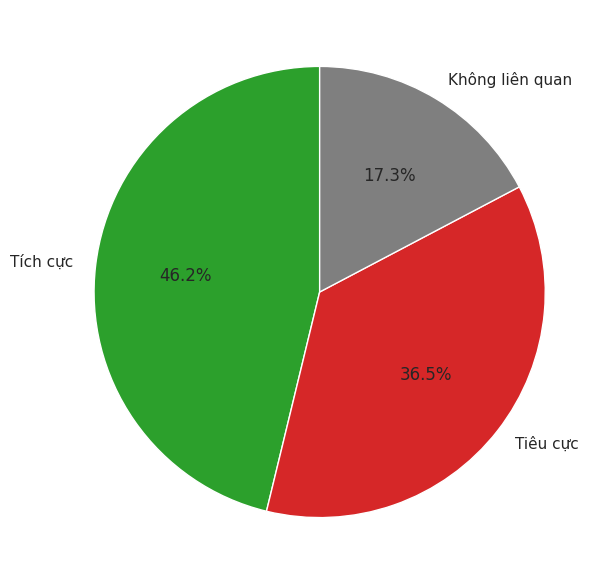

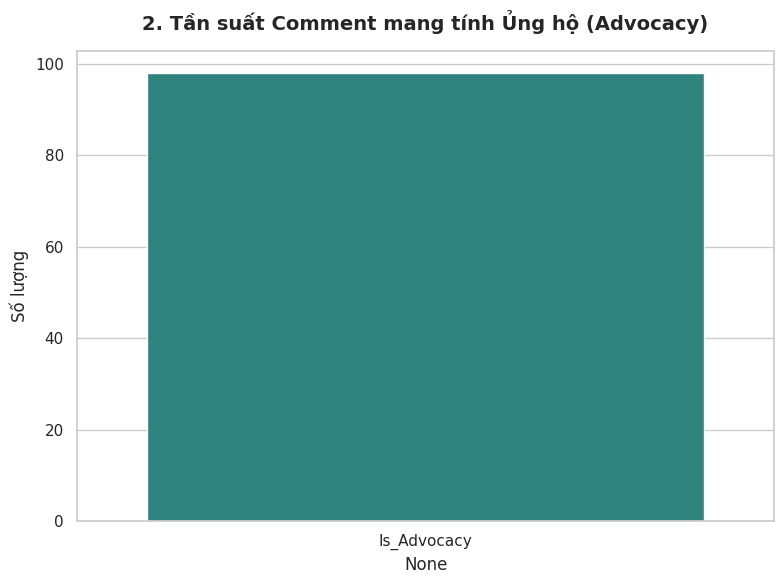

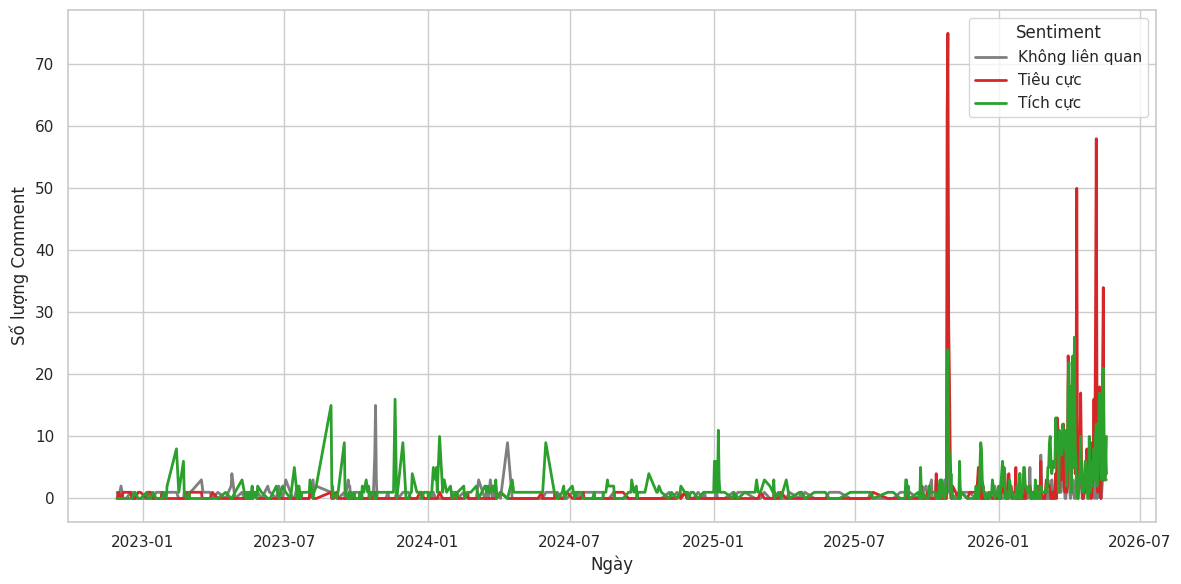

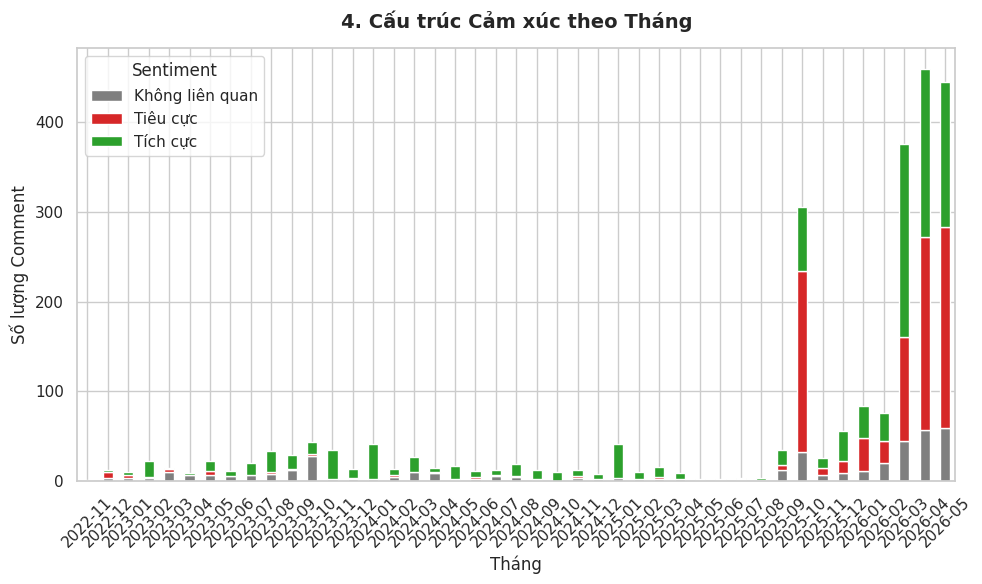

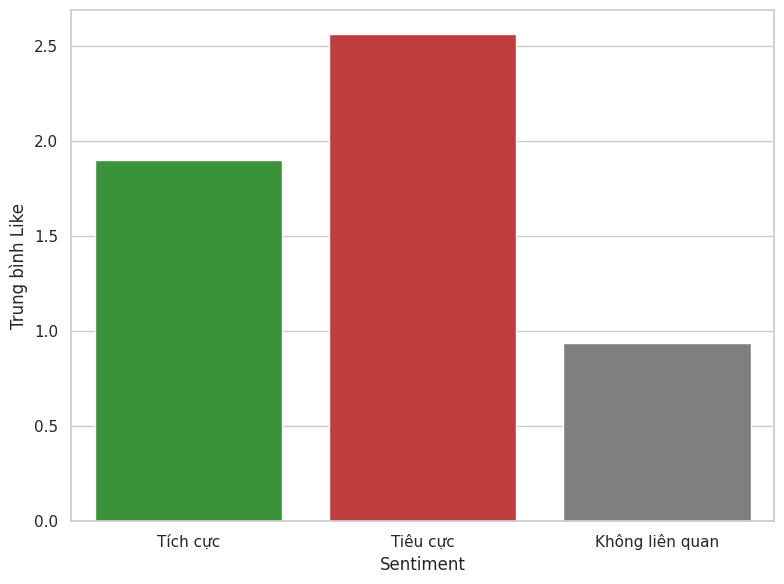

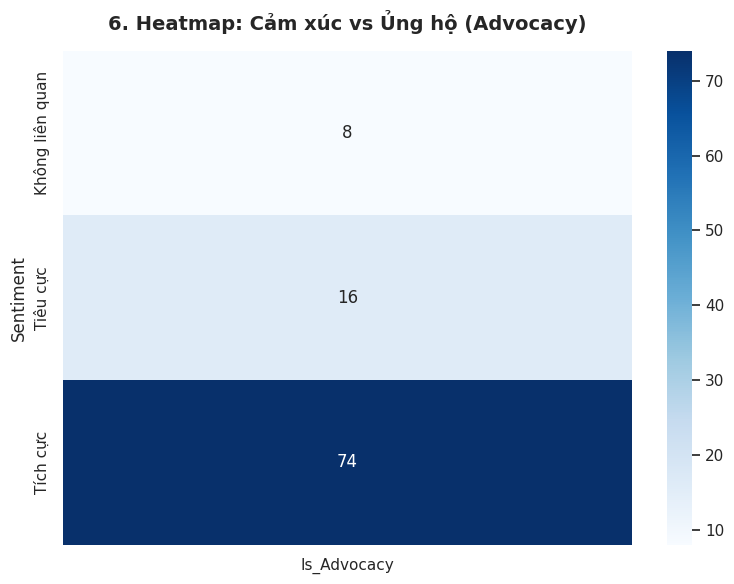

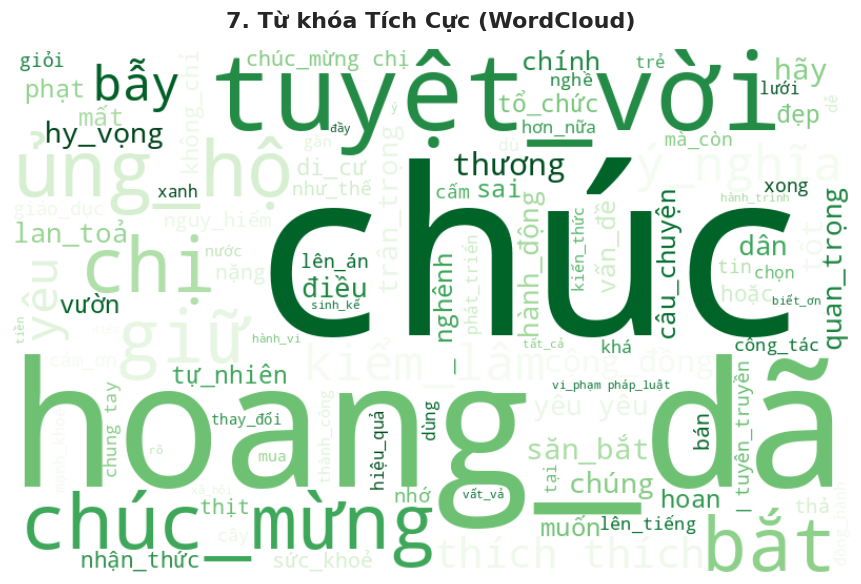

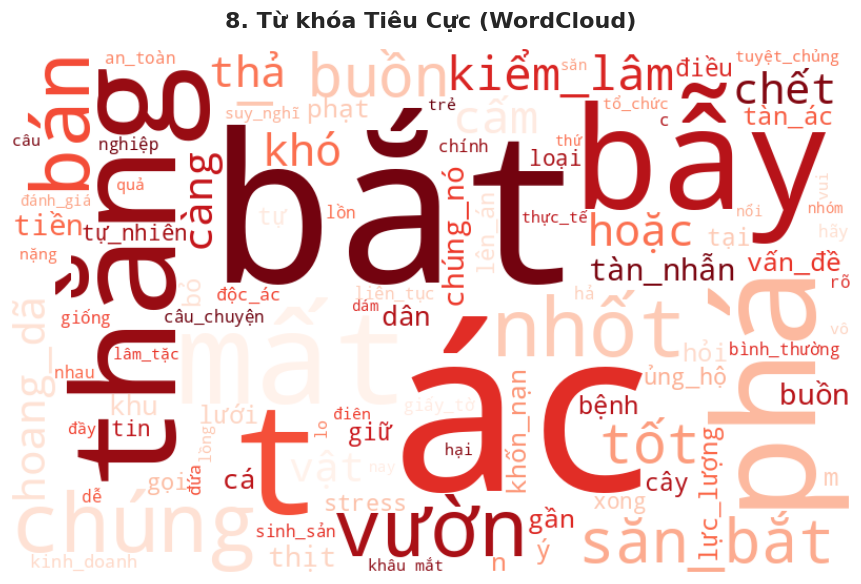

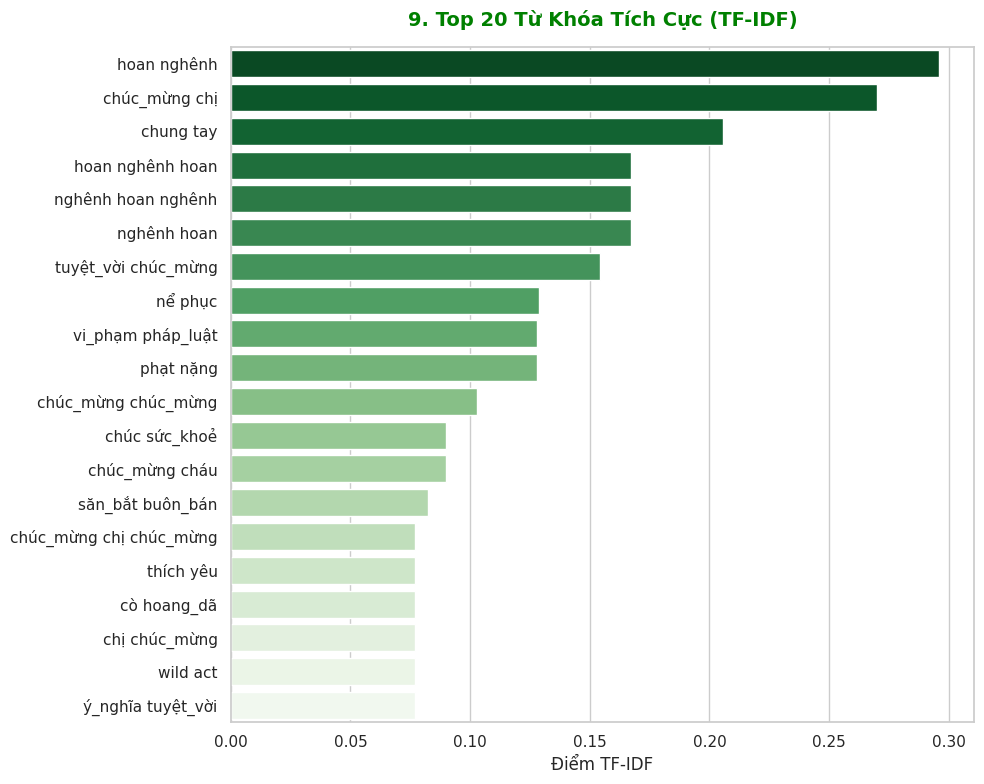

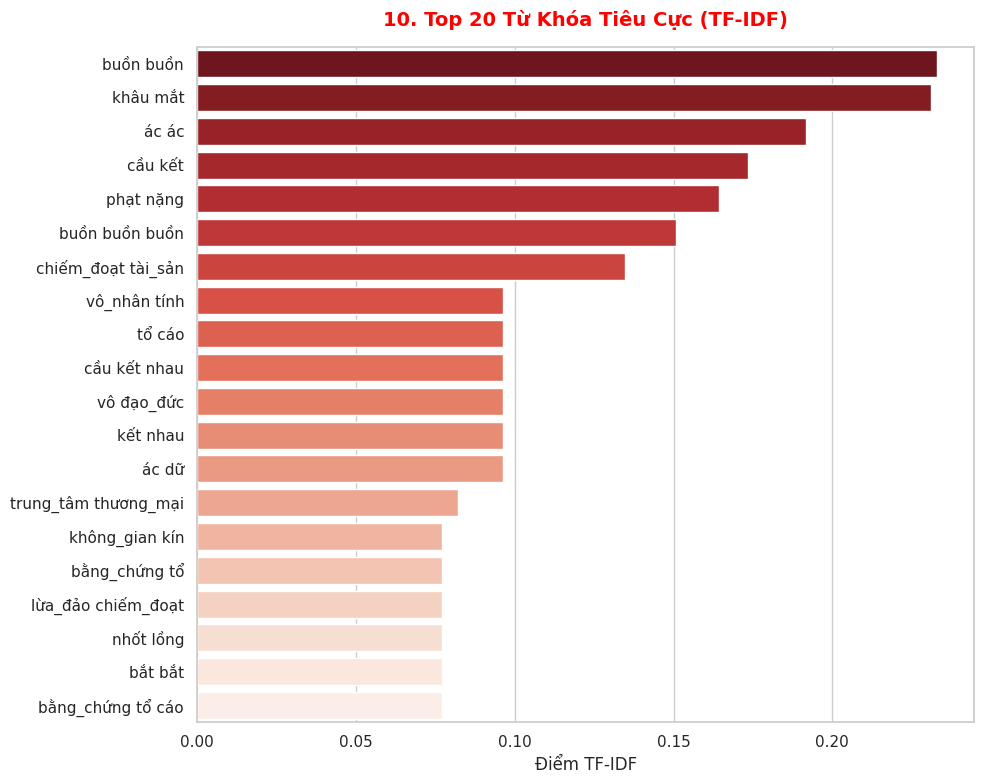

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings("ignore")

# 1. THIẾT LẬP FONT VÀ STYLE CƠ BẢN
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False


# ---------------------------------------------------------
# BƯỚC 1: ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU
# ---------------------------------------------------------
file_path = '/content/comments_with_posts.csv'

try:
    df = pd.read_csv(file_path)

    # CHUẨN HÓA TÊN CỘT ĐỂ KHỚP VỚI HỆ THỐNG CODE BÊN DƯỚI
    df = df.rename(columns={
        'Label (pos:1, neg:0,irre:2)': 'Label',
        'cleaned_text': 'Cleaned_Text'
    })

except FileNotFoundError:
    print("Không tìm thấy file, đang dùng dữ liệu mẫu...")
    np.random.seed(42)
    dates = pd.date_range(start='2025-01-01', periods=100, freq='D')
    df = pd.DataFrame({
        'Post_ID': np.random.randint(1, 10, 100),
        'date': np.random.choice(dates, 100),
        'likesCount': np.random.randint(0, 50, 100),
        'Is_Advocacy': np.random.choice([0, 1], 100, p=[0.8, 0.2]),
        # Dữ liệu mẫu đã bỏ Is_Tagging và Is_Question vì file thật không có
        'Label': np.random.choice([0, 1, 2], 100, p=[0.3, 0.5, 0.2]),
        'Cleaned_Text': ['sản phẩm tốt', 'tệ quá', 'không liên quan', 'đẹp', 'hỏng rồi'] * 20
    })

# Đảm bảo Label là dạng số
df['Label'] = pd.to_numeric(df['Label'], errors='coerce')

# Xử lý thời gian và Map nhãn Cảm xúc
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['Month'] = df['date'].dt.to_period('M')
label_mapping = {0: 'Tiêu cực', 1: 'Tích cực', 2: 'Không liên quan'}
df['Sentiment'] = df['Label'].map(label_mapping)
color_dict = {'Tích cực': '#2ca02c', 'Tiêu cực': '#d62728', 'Không liên quan': '#7f7f7f'}

# ---------------------------------------------------------
# BƯỚC 2: CÁC BIỂU ĐỒ TỔNG QUAN (TÁCH RIÊNG)
# ---------------------------------------------------------

# --- Biểu đồ 1: Biểu đồ tròn Tỷ lệ Cảm xúc ---
plt.figure(figsize=(8, 6))
sentiment_counts = df['Sentiment'].value_counts()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
        startangle=90, colors=[color_dict.get(x, '#333333') for x in sentiment_counts.index])
#plt.title('1. Tỷ lệ Cảm xúc Tổng quan', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# --- Biểu đồ 2: Tần suất Comment Đặc biệt (Chỉ còn Is_Advocacy) ---
plt.figure(figsize=(8, 6))
features_sum = df[['Is_Advocacy']].sum()
sns.barplot(x=features_sum.index, y=features_sum.values, palette='viridis')
plt.title('2. Tần suất Comment mang tính Ủng hộ (Advocacy)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()

# --- Biểu đồ 3: Xu hướng Cảm xúc theo Ngày ---
plt.figure(figsize=(12, 6))
daily_sentiment = df.groupby([df['date'].dt.date, 'Sentiment']).size().unstack(fill_value=0)
daily_sentiment.plot(kind='line', ax=plt.gca(), color=[color_dict.get(x) for x in daily_sentiment.columns], linewidth=2)
#plt.title('3. Xu hướng Cảm xúc theo Ngày', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ngày')
plt.ylabel('Số lượng Comment')
plt.tight_layout()
plt.show()

# --- Biểu đồ 4: Cấu trúc Cảm xúc theo Tháng ---
plt.figure(figsize=(10, 6))
monthly_sentiment = df.groupby(['Month', 'Sentiment']).size().unstack(fill_value=0)
monthly_sentiment.plot(kind='bar', stacked=True, ax=plt.gca(), color=[color_dict.get(x) for x in monthly_sentiment.columns])
plt.title('4. Cấu trúc Cảm xúc theo Tháng', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tháng')
plt.ylabel('Số lượng Comment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Biểu đồ 5: Lượt Like trung bình theo Cảm xúc ---
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Sentiment', y='likesCount', estimator='mean', errorbar=None, palette=color_dict)
#plt.title('5. Lượt Like Trung bình mỗi Comment', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Trung bình Like')
plt.tight_layout()
plt.show()

# --- Biểu đồ 6: Heatmap Mối quan hệ Hành vi và Cảm xúc ---
plt.figure(figsize=(8, 6))
# Vì file chỉ có Is_Advocacy nên heatmap sẽ chỉ có 1 cột
behavior_sentiment = df.groupby('Sentiment')[['Is_Advocacy']].sum()
sns.heatmap(behavior_sentiment, annot=True, fmt='g', cmap='Blues')
plt.title('6. Heatmap: Cảm xúc vs Ủng hộ (Advocacy)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# BƯỚC 3: ĐÁM MÂY TỪ (WORDCLOUD) - TÁCH RIÊNG
# ---------------------------------------------------------
vietnamese_stopwords = set([
    "không", "mình", "người", "rất", "nhiều", "thấy", "sẽ", "đi", "mới", "cũng", "phải", "hơn", "làm", "còn", "bạn", "lại", "nhưng", "gì", "cái", "nó", "mấy", "rồi", "đâu", "đã", "đang", "được", "có", "là", "và", "thì", "mà", "của", "cho", "ở", "vào", "ra", "để", "này", "kia", "rằng", "thế", "như", "nào", "chỉ", "với", "những", "các", "đến", "từ", "rừng", "bảo_vệ", "động_vật", "thú", "ăn", "việc", "nhà", "nên", "biết", "họ", "quá", "cần", "vì", "luôn", "sự", "đó", "bài", "mọi", "có_thể", "cả", "tôi", "nói", "chứ", "vẫn", "nữa", "thôi", "vậy", "năm", "thật", "thật_sự", "đáng", "chưa", "kể", "bao_nhiêu", "nơi", "như_vậy", "hàng", "ngày", "nhé", "môi_trường", "sống", "bảo_tồn", "thiên_nhiên", "con_người", "loài", "người_dân", "nuôi", "mô_hình", "kiểu", "đọc", "viết", "đăng", "lên", "lấy", "chồng", "chế_độ", "mẫu_hệ", "gia_đình", "phụ_nữ", "nhân_viên", "anh_em", "chị_em", "cá_nhân", "bé", "con", "bà", "các_bạn", "tháng", "thời_gian", "hoạt_động", "công_việc", "sự_kiện", "chương_trình", "dự_án", "cơ_hội", "bức", "chiếc", "tiếp_tục", "tham_gia", "thực_hiện", "cảm_ơn", "đóng_góp", "hỗ_trợ", "gửi", "nhận", "mong", "hiểu", "chia_sẻ", "mang", "đặt", "kêu", "sợ", "cố_gắng", "tìm", "tạo", "giúp", "gặp", "cùng", "nhất", "cách", "thường", "lắm", "đến_nay", "ít", "khác", "nhỏ", "lớn", "nếu", "trên"
])

new_stopwords = [
    "anh", "em", "ai", "bọn", "tụi", "ta", "ông", "kẻ", "chúng_ta", "đấy", "đây", "lũ",
    "trong", "về", "một", "khi", "qua", "tới", "vài", "toàn", "lúc", "giờ", "do", "sau", "trước", "chỗ",
    "hay", "xin", "bị", "cứ", "đừng", "chịu", "bảo", "dẹp", "hết", "thẳng", "thêm", "vừa", "đúng", "chơi", "đưa",
    "sao", "tm", "chả", "v", "ac",
    "wildact", "việt_nam",


    #####
    "ấy", "nhỉ", "ơi", "á", "trời", "tại_sao","nghĩ", "nhìn", "xem", "nghe", "từng", "vẫn_đề", "kiếm", "bằng", "chắc", "đủ", "lần", "ngoài", "bên", "đều", "mỗi", "theo", "đầu","chim",


    #####
    "trang", "chị_trang", "thanh", "nga", "thanh_nga",
    "di", "đà", "phật", "di_đà", "đà_phật", "a_di_đà_phật",
    "nh", "ba", "tô",
    "chư", "yang", "sin", "chư_yang_sin","wild act"
]

# Thêm vào tập (set) stopwords cũ của bạn
vietnamese_stopwords.update(new_stopwords)

def plot_wordcloud(text_data, title, colormap):
    if not text_data.empty:
        text = " ".join(str(v).lower() for v in text_data.dropna())
        wc = WordCloud(
            width=800, height=500, background_color='white',
            colormap=colormap, stopwords=vietnamese_stopwords,
            max_words=100, min_font_size=10
        ).generate(text)

        plt.figure(figsize=(10, 6))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(title, fontsize=16, fontweight='bold', pad=15)
        plt.tight_layout()
        plt.show()

# --- Biểu đồ 7: WordCloud Tích cực ---
positive_text = df[df['Label'] == 1]['Cleaned_Text']
plot_wordcloud(positive_text, '7. Từ khóa Tích Cực (WordCloud)', 'Greens')

# --- Biểu đồ 8: WordCloud Tiêu cực ---
negative_text = df[df['Label'] == 0]['Cleaned_Text']
plot_wordcloud(negative_text, '8. Từ khóa Tiêu Cực (WordCloud)', 'Reds')


def remove_consecutive_duplicates_pro(text):
    if pd.isna(text):
        return text

    # Ép kiểu string, chuyển chữ thường và tách thành danh sách các từ
    words = str(text).lower().split()
    if not words:
        return text

    cleaned_words = [words[0]]
    for word in words[1:]:
        # Chỉ thêm vào danh sách nếu từ hiện tại KHÁC từ ngay trước nó
        if word != cleaned_words[-1]:
            cleaned_words.append(word)

    return " ".join(cleaned_words)

# Áp dụng hàm mới vào dữ liệu
df['Cleaned_Text'] = df['Cleaned_Text'].apply(remove_consecutive_duplicates_pro)

# ----- SAU ĐÓ MỚI CHẠY TF-IDF BÊN DƯỚI -----

# ---------------------------------------------------------
# BƯỚC 4: TF-IDF (TÁCH RIÊNG)
# ---------------------------------------------------------
df_clean = df.dropna(subset=['Cleaned_Text'])

# Kiểm tra xem có đủ dữ liệu cho cả 2 nhãn không trước khi chạy TF-IDF
if len(df_clean[df_clean['Label'] == 0]) > 0 and len(df_clean[df_clean['Label'] == 1]) > 0:
    neg_text = " ".join(df_clean[df_clean['Label'] == 0]['Cleaned_Text'].astype(str))
    pos_text = " ".join(df_clean[df_clean['Label'] == 1]['Cleaned_Text'].astype(str))

    vectorizer = TfidfVectorizer(max_features=2000, stop_words=list(vietnamese_stopwords), ngram_range=(2, 3))
    tfidf_matrix = vectorizer.fit_transform([neg_text, pos_text])

    feature_names = vectorizer.get_feature_names_out()
    neg_scores = tfidf_matrix[0].toarray().flatten()
    pos_scores = tfidf_matrix[1].toarray().flatten()

    df_tfidf = pd.DataFrame({'Word': feature_names, 'Negative_Score': neg_scores, 'Positive_Score': pos_scores})

    top20_neg = df_tfidf.sort_values(by='Negative_Score', ascending=False).head(20)
    top20_pos = df_tfidf.sort_values(by='Positive_Score', ascending=False).head(20)

    # --- Biểu đồ 9: TF-IDF Tích cực ---
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Positive_Score', y='Word', data=top20_pos, palette='Greens_r')
    plt.title('9. Top 20 Từ Khóa Tích Cực (TF-IDF)', fontsize=14, color='green', fontweight='bold', pad=15)
    plt.xlabel('Điểm TF-IDF')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

    # --- Biểu đồ 10: TF-IDF Tiêu cực ---
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Negative_Score', y='Word', data=top20_neg, palette='Reds_r')
    plt.title('10. Top 20 Từ Khóa Tiêu Cực (TF-IDF)', fontsize=14, color='red', fontweight='bold', pad=15)
    plt.xlabel('Điểm TF-IDF')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Không đủ dữ liệu cho cả 2 nhãn Tích cực và Tiêu cực để chạy TF-IDF.")

In [5]:
import pandas as pd
import re
import urllib.parse

# ==========================================
# 1. ĐỌC DỮ LIỆU
# ==========================================
path_posts = "/content/WildAct_Assigned_Topics.csv"
path_comments = "/content/comments_with_posts.csv"

df_posts = pd.read_csv(path_posts)
df_comments = pd.read_csv(path_comments)

# ==========================================
# 2. CHẠY DEBUG - TÌM NGUYÊN NHÂN LỖI
# ==========================================
print("="*60)
print("🔍 DEBUG 1: KIỂM TRA ĐỊNH DẠNG URL GỐC")
print("="*60)
print("➜ 3 URL đầu tiên từ bảng Comments (facebookUrl):")
for url in df_comments['facebookUrl'].dropna().head(3):
    print(f"[{len(url)} ký tự] {url}")

print("\n➜ 3 URL đầu tiên từ bảng Posts (url):")
for url in df_posts['url'].dropna().head(3):
    print(f"[{len(url)} ký tự] {url}")

print("\n" + "="*60)
print("🔍 DEBUG 2: KIỂM TRA MỘT URL CỤ THỂ")
print("="*60)
# Lấy URL đầu tiên của Post để tìm trong Comment
sample_post_url = str(df_posts['url'].dropna().iloc[0])
print(f"Đang tìm URL: {sample_post_url}")
# Thử tìm một phần của chuỗi (chống lỗi do m.facebook hay www)
partial_match = df_comments[df_comments['facebookUrl'].str.contains(sample_post_url[:30], na=False, regex=False)]
print(f"➜ Tìm thấy {len(partial_match)} comment khớp một phần URL này.")

if len(partial_match) > 0:
    print(f"URL gốc trong file Comment là: {partial_match['facebookUrl'].iloc[0]}")
    print("=> HÃY SO SÁNH BẰNG MẮT ĐỂ THẤY SỰ KHÁC BIỆT CỦA 2 URL TRÊN!")


# ==========================================
# 3. GIẢI PHÁP TỐI THƯỢNG: GHÉP BẢNG BẰNG POST ID
# ==========================================
print("\n" + "="*60)
print("🚀 TIẾN HÀNH GHÉP BẢNG BẰNG POST ID (BỎ QUA URL)")
print("="*60)

# Hàm giải mã URL và trích xuất ID (chuỗi số dài đại diện cho bài viết)
def extract_post_id(url):
    if pd.isna(url): return None
    url = urllib.parse.unquote(str(url)) # Giải mã các ký tự như %2F
    # Tìm tất cả các cụm số có từ 8 chữ số trở lên (ID của facebook thường rất dài)
    matches = re.findall(r'\d{8,}', url)
    if matches:
        return matches[-1] # Thường ID bài viết sẽ nằm ở cụm số cuối cùng
    return None

# Tạo cột ID dùng để ghép
df_comments['post_id_match'] = df_comments['facebookUrl'].apply(extract_post_id)
df_posts['post_id_match'] = df_posts['url'].apply(extract_post_id)

# Thống kê việc tách ID
print(f"Đã tách được ID cho {df_comments['post_id_match'].notna().sum()} / {len(df_comments)} comments.")
print(f"Đã tách được ID cho {df_posts['post_id_match'].notna().sum()} / {len(df_posts)} posts.")

# Xóa các dòng post trùng lặp ID (để tránh nhân bản comment khi ghép)
df_posts = df_posts.drop_duplicates(subset=['post_id_match'])

# Thực hiện Join 2 bảng
df_merged = pd.merge(
    df_comments,
    df_posts,
    how='left',
    on='post_id_match', # KHÓA GHÉP NỐI LÀ ID BÀI VIẾT
    suffixes=('', '_drop')
)

# ==========================================
# 4. LOẠI BỎ CỘT TRÙNG LẶP & LƯU KẾT QUẢ
# ==========================================
duplicate_columns = [col for col in df_merged.columns if col.endswith('_drop')]
df_merged.drop(columns=duplicate_columns, inplace=True)

if 'url' in df_merged.columns:
    df_merged.drop(columns=['url'], inplace=True)

if 'Cleaned_Text' in df_merged.columns and 'cleaned_text' in df_merged.columns:
    df_merged = df_merged.rename(columns={'Cleaned_Text': 'Cleaned_Text_Post', 'cleaned_text': 'Cleaned_Text_Comment'})

# Xóa cột ID tạm
df_merged.drop(columns=['post_id_match'], inplace=True)

missing_topics = df_merged['Topic_ID'].isnull().sum()
total_rows = len(df_merged)
print(f"\n✅ Kết quả: {total_rows - missing_topics} comment ĐÃ ĐƯỢC GẮN TOPIC thành công!")
print(f"❌ Số comment không tìm thấy post tương ứng: {missing_topics} / {total_rows}")

output_path = "Merged_Comments_With_Topics.csv"
df_merged.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu file tại: {output_path}")

🔍 DEBUG 1: KIỂM TRA ĐỊNH DẠNG URL GỐC
➜ 3 URL đầu tiên từ bảng Comments (facebookUrl):
[113 ký tự] https://www.facebook.com/WildActvn/posts/pfbid02NY9fsBTJm3RHa9gU9LEfTjePAZN1y6xGGZJKNV6NqaRLsPoGmVQMY9HrTfvu4twtl
[113 ký tự] https://www.facebook.com/WildActvn/posts/pfbid02NY9fsBTJm3RHa9gU9LEfTjePAZN1y6xGGZJKNV6NqaRLsPoGmVQMY9HrTfvu4twtl
[113 ký tự] https://www.facebook.com/WildActvn/posts/pfbid02NY9fsBTJm3RHa9gU9LEfTjePAZN1y6xGGZJKNV6NqaRLsPoGmVQMY9HrTfvu4twtl

➜ 3 URL đầu tiên từ bảng Posts (url):
[113 ký tự] 	https://www.facebook.com/WildActvn/posts/pfbid0EcV97Ng4gkVaA1MsuMbCx1ptZMsGL1QsDdVqmvBoh5zdw7W4CfyGFqUieBP87rVUl
[114 ký tự] 	https://www.facebook.com/WildActvn/posts/pfbid02iZ455YHbKyQsZym4xHw4jhPhcdTVRjDLb66EN6sMrK5ifoehMqFjqjzSmZ1YoiKPl
[113 ký tự] 	https://www.facebook.com/WildActvn/posts/pfbid03chVXo2F1Eg2XqCznQWvsum7hgDnjMm74zE55aRcBHGVAYBSWi3zNNGsEUXFZ2Eal

🔍 DEBUG 2: KIỂM TRA MỘT URL CỤ THỂ
Đang tìm URL: 	https://www.facebook.com/WildActvn/posts/pfbid0EcV97Ng4gkVaA1MsuMb

In [27]:
import pandas as pd
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

print("="*80)
print("🚀 BƯỚC 1: ĐỌC DỮ LIỆU & GẮN TÊN TOPIC")
print("="*80)

# ==========================================
# 1. ĐỌC DỮ LIỆU ĐÃ MERGE TỪ BƯỚC TRƯỚC
# ==========================================
file_path = "/content/comments_with_posts_updated.csv"
df_final = pd.read_csv(file_path)

# ==========================================
# 2. ÁNH XẠ (MAP) TÊN TOPIC MỚI NHẤT
# ==========================================
topic_mapping = {
    -1: 'Nhiễu / Outliers',
    0: 'Câu chuyện thực địa và Tôn vinh Kiểm lâm',
    1: 'Đào tạo & Phát triển nhà bảo tồn trẻ', # <--- ĐÃ CẬP NHẬT TẠI ĐÂY
    2: 'Giám sát bẫy ảnh và Cứu hộ ĐVHD', # Rút gọn tên để hiển thị biểu đồ đẹp hơn
    3: 'Vai trò Phụ nữ và Bình đẳng giới',
    4: 'Ngăn chặn săn bắt và Bảo tồn chim di cư',
    5: 'Giáo dục trải nghiệm và Ngoại khóa',
    6: 'Tuyển dụng và Xây dựng đội ngũ',
    7: 'Giải thưởng Giữ Rừng',
    8: 'Chiến dịch Gây quỹ và Minh bạch tài chính',
    9: 'Cuộc thi Nghệ thuật sáng tạo và Truyền thông',
    10: 'Phúc lợi Động vật',
    11: 'Chiến dịch Mầm non của Rừng',
    12: 'Trồng rừng bản địa và Khí hậu'
}

# Tạo cột Tên Topic
df_final['Post_Topic_Name'] = df_final['Topic_ID'].map(topic_mapping)

print("✅ Đã gắn tên Topic thành công!")


print("\n" + "="*80)
print("📊 BƯỚC 2: VẼ BIỂU ĐỒ PHÂN TÍCH INSIGHTS")
print("="*80)

# Lọc bỏ các dữ liệu thuộc Topic -1 (Nhiễu) trước khi vẽ
df_clean_comments = df_final[df_final['Topic_ID'] != -1].copy()

# =================================================================
# BIỂU ĐỒ 1: ĐỘ HOT (TƯƠNG TÁC) THEO TỪNG TOPIC
# =================================================================
df_unique_posts = df_clean_comments.drop_duplicates(subset=['inputUrl']).copy()

# Đảm bảo các cột tương tác là dạng số
for col in ['likes', 'comments', 'shares']:
    df_unique_posts[col] = pd.to_numeric(df_unique_posts[col], errors='coerce').fillna(0)

df_unique_posts['Hotness'] = df_unique_posts['likes'] + df_unique_posts['comments'] + df_unique_posts['shares']

hotness_by_topic = df_unique_posts.groupby('Post_Topic_Name')['Hotness'].sum().reset_index()
hotness_by_topic = hotness_by_topic.sort_values(by='Hotness', ascending=True)

fig1 = px.bar(
    hotness_by_topic,
    x='Hotness',
    y='Post_Topic_Name',
    orientation='h',
    labels={'Hotness': 'Tổng Tương Tác (Like + Cmt + Share)', 'Post_Topic_Name': 'Chủ đề (Topic)'},
    color_discrete_sequence=['#3498db']
)
fig1.update_layout(width=900, height=700)
fig1.show()


# =================================================================
# BIỂU ĐỒ 2: SỐ LƯỢNG HÀNH ĐỘNG ỦNG HỘ (IS_ADVOCACY) THEO TOPIC
# =================================================================
df_clean_comments['Is_Advocacy'] = pd.to_numeric(df_clean_comments['Is_Advocacy'], errors='coerce').fillna(0)

advocacy_by_topic = df_clean_comments.groupby('Post_Topic_Name')['Is_Advocacy'].sum().reset_index()
advocacy_by_topic = advocacy_by_topic.sort_values(by='Is_Advocacy', ascending=True)

fig2 = px.bar(
    advocacy_by_topic,
    x='Is_Advocacy',
    y='Post_Topic_Name',
    orientation='h',
    labels={'Is_Advocacy': 'Số lượng lượt ủng hộ', 'Post_Topic_Name': 'Chủ đề (Topic)'},
    color_discrete_sequence=['#2ecc71']
)
fig2.update_layout(width=900, height=700)
                   #title="Số Lượng Bình Luận Chứa Yếu Tố Ủng Hộ/Hành Động Theo Topic")
fig2.show()


# =================================================================
# BIỂU ĐỒ 3: PHÂN BỔ CẢM XÚC (SENTIMENT) THEO TOPIC (100% STACKED)
# =================================================================
# Lọc bỏ nhãn 2 (Không liên quan)
df_sentiment = df_clean_comments[df_clean_comments['Label'].isin([0, 1])].copy()
df_sentiment['Sentiment'] = df_sentiment['Label'].map({0: 'Tiêu cực', 1: 'Tích cực'})

# Đếm số lượng tích cực/tiêu cực cho từng Topic
sentiment_dist = df_sentiment.groupby(['Post_Topic_Name', 'Sentiment']).size().reset_index(name='Count')

# Tính tổng số lượng bình luận của mỗi Topic để làm mẫu số
total_per_topic = sentiment_dist.groupby('Post_Topic_Name')['Count'].transform('sum')

# Tính tỷ lệ phần trăm và tạo cột text để hiển thị (ví dụ: 85.5%)
sentiment_dist['Percentage'] = (sentiment_dist['Count'] / total_per_topic) * 100
sentiment_dist['Text_Label'] = sentiment_dist['Percentage'].round(1).astype(str) + '%'

# Vẽ biểu đồ với trục X là Phần trăm (Percentage) thay vì Count
fig3 = px.bar(
    sentiment_dist,
    x='Percentage', # Chuyển sang dùng % để tất cả các cột đều full 100%
    y='Post_Topic_Name',
    color='Sentiment',
    orientation='h',
    labels={'Percentage': 'Tỷ lệ Cảm xúc (%)', 'Post_Topic_Name': 'Chủ đề (Topic)'},
    color_discrete_map={'Tích cực': '#2ecc71', 'Tiêu cực': '#e74c3c'},
    text='Text_Label', # Hiển thị số % trực tiếp lên biểu đồ
    barmode='stack'
)

# Ép text nằm ngay ngắn ở chính giữa từng khối màu của cột
fig3.update_traces(textposition='inside', insidetextanchor='middle')

fig3.update_layout(width=1000, height=700)
# fig3.update_layout(title="Phân Bổ Cảm Xúc Bình Luận Theo Từng Topic (Tỷ lệ %)")
fig3.show()

# =================================================================
# BIỂU ĐỒ 4: NHÂN KHẨU HỌC (GIỚI TÍNH) THEO TOPIC
# =================================================================
df_gender = df_clean_comments.dropna(subset=['gender']).copy()
df_gender = df_gender[df_gender['gender'].str.lower().isin(['nam', 'nữ', 'male', 'female'])]
df_gender['gender'] = df_gender['gender'].str.capitalize().replace({'Male': 'Nam', 'Female': 'Nữ'})

gender_dist = df_gender.groupby(['Post_Topic_Name', 'gender']).size().reset_index(name='Count')

fig4 = px.bar(
    gender_dist,
    x='Count',
    y='Post_Topic_Name',
    color='gender',
    orientation='h',
    labels={'Count': 'Số lượng bình luận', 'Post_Topic_Name': 'Chủ đề (Topic)'},
    color_discrete_map={'Nam': '#3498db', 'Nữ': '#f39c12'},
    barmode='group'
)
fig4.update_layout(width=1000, height=800)
                   #title="Sự Tham Gia Bình Luận Của Nam/Nữ Theo Từng Topic")
fig4.show()

🚀 BƯỚC 1: ĐỌC DỮ LIỆU & GẮN TÊN TOPIC
✅ Đã gắn tên Topic thành công!

📊 BƯỚC 2: VẼ BIỂU ĐỒ PHÂN TÍCH INSIGHTS


In [20]:
import pandas as pd
import json
import ast

print("⏳ BƯỚC 1: ĐỌC DỮ LIỆU...")
# Thay bằng đường dẫn file của bạn
file_path = "/content/comments_with_posts_v2.csv"
df = pd.read_csv(file_path)

# ==========================================
# RESET TOÀN BỘ CỘT VỀ 0
# ==========================================
print("🔄 BƯỚC 2: RESET toàn bộ cột Is_Advocacy về 0...")
df['Is_Advocacy'] = 0

# ==========================================
# BỘ TỪ KHÓA NGÂN HÀNG/ỦNG HỘ
# ==========================================
banking_keywords = [
    "chuyển khoản", "ck", "số tài khoản", "stk", "ngân hàng", "bank",
    "vietcombank", "vcb", "techcombank", "tcb", "mbbank", "mb bank",
    "bidv", "acb", "tpbank", "vpbank", "agribank", "sacombank",
    "chuyển tiền", "giao dịch thành công", "chuyển thành công",
    "ủng hộ", "quyên góp", "chuyển đến"
]

# ==========================================
# HÀM KIỂM TRA OCR TEXT TỪ JSON
# ==========================================
def check_advocacy_from_media(media_val):
    if pd.isna(media_val) or str(media_val).strip() == "":
        return 0

    media_str = str(media_val)

    try:
        media_list = json.loads(media_str)
    except:
        try:
            media_list = ast.literal_eval(media_str)
        except:
            return 0

    if not isinstance(media_list, list):
        return 0

    for item in media_list:
        if isinstance(item, dict):
            ocr_text = item.get("ocrText", "")

            if ocr_text:
                ocr_text_lower = str(ocr_text).lower()
                for keyword in banking_keywords:
                    if keyword in ocr_text_lower:
                        return 1 # Phát hiện từ khóa -> trả về 1

    return 0

print("🔍 BƯỚC 3: Đang quét cột 'media' (OCR) để cập nhật lại Is_Advocacy...")
# Quét và ghi đè trực tiếp kết quả (0 hoặc 1) vào cột Is_Advocacy
df['Is_Advocacy'] = df['media'].apply(check_advocacy_from_media)


# ==========================================
# LƯU KẾT QUẢ VÀ BÁO CÁO
# ==========================================
output_path = "/content/comments_with_posts_updated.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')

total_advocacy = df['Is_Advocacy'].sum()
print(f"✅ BƯỚC 4: Hoàn tất! Đã lưu file tại: {output_path}")
print(f"📊 Tổng số bình luận được xác định là Ủng hộ (qua ảnh chụp bill): {int(total_advocacy)}")

⏳ BƯỚC 1: ĐỌC DỮ LIỆU...
🔄 BƯỚC 2: RESET toàn bộ cột Is_Advocacy về 0...
🔍 BƯỚC 3: Đang quét cột 'media' (OCR) để cập nhật lại Is_Advocacy...
✅ BƯỚC 4: Hoàn tất! Đã lưu file tại: /content/comments_with_posts_updated.csv
📊 Tổng số bình luận được xác định là Ủng hộ (qua ảnh chụp bill): 14


In [30]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score, confusion_matrix

# ==========================================
# 1. ĐỌC FILE CSV
# ==========================================

file_path = "/content/cohen_kappa.csv"   # đổi thành tên file của bạn

df = pd.read_csv(file_path)

# ==========================================
# 2. KIỂM TRA DỮ LIỆU
# ==========================================

print("Preview dữ liệu:")
print(df.head())

# ==========================================
# 3. LOẠI BỎ DÒNG THIẾU NHÃN
# ==========================================

df = df.dropna(subset=["Label_1", "Label_2"])

# ép kiểu int
df["Label_1"] = df["Label_1"].astype(int)
df["Label_2"] = df["Label_2"].astype(int)

# ==========================================
# 4. TÍNH COHEN'S KAPPA
# ==========================================

kappa = cohen_kappa_score(
    df["Label_1"],
    df["Label_2"]
)

print("\n" + "="*60)
print(f"Cohen's Kappa Score: {kappa:.4f}")
print("="*60)

# ==========================================
# 5. MA TRẬN ĐỒNG THUẬN
# ==========================================

cm = confusion_matrix(
    df["Label_1"],
    df["Label_2"]
)

print("\nMa trận đồng thuận:")
print(cm)

# ==========================================
# 6. DIỄN GIẢI KAPPA
# ==========================================

if kappa < 0:
    interpretation = "Poor agreement"
elif kappa < 0.20:
    interpretation = "Slight agreement"
elif kappa < 0.40:
    interpretation = "Fair agreement"
elif kappa < 0.60:
    interpretation = "Moderate agreement"
elif kappa < 0.80:
    interpretation = "Substantial agreement"
else:
    interpretation = "Almost perfect agreement"

print(f"\nMức độ đồng thuận: {interpretation}")

Preview dữ liệu:
   STT                                            comment  Label_1  Label_2
0    1  cũng là một thợ_săn chim vũ_khí của là máy_ảnh...        1        1
1    2  tôi dân quảng_ninh vừa có biển vừa có rừng mà ...        1        1
2    3  nhiều vẫn nghĩ không nằm trong danh_sách bảo_t...        0        0
3    4  mỗi loại đều có_vẻ đẹp riêng có loài để cân_bằ...        1        1
4    5  ao tôm bị chim biển vào lây bệnh giăng lưới cá...        0        0

Cohen's Kappa Score: 0.6679

Ma trận đồng thuận:
[[23  2  0]
 [ 4 17  0]
 [ 1  2  1]]

Mức độ đồng thuận: Substantial agreement


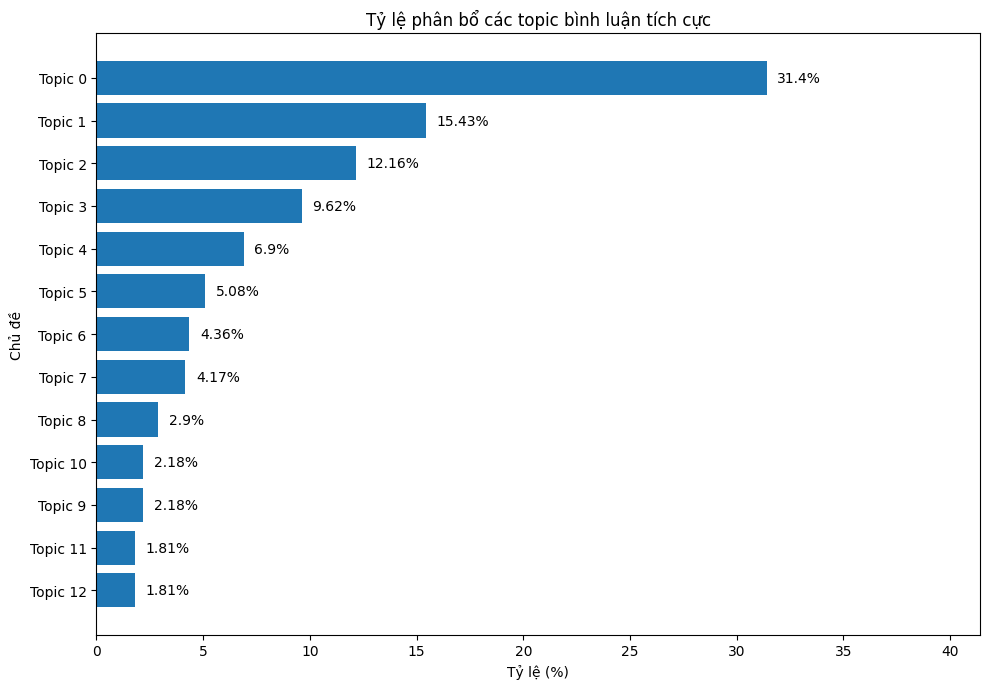

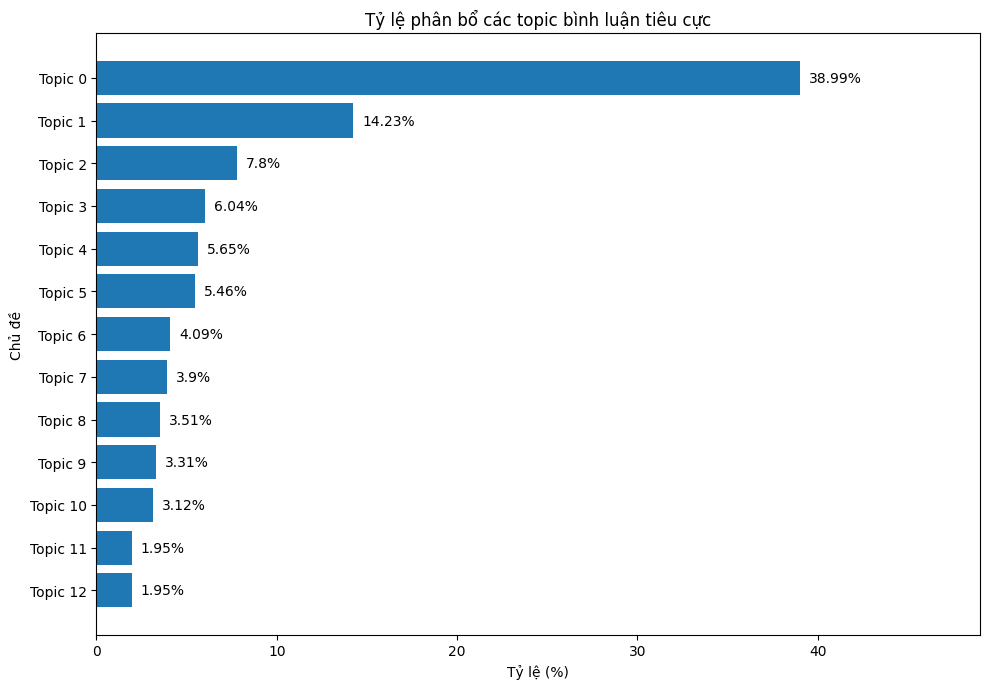

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# DỮ LIỆU TOPIC - TÍCH CỰC
# ==========================================

positive_topics = {
    "Topic 0": 173,
    "Topic 1": 85,
    "Topic 2": 67,
    "Topic 3": 53,
    "Topic 4": 38,
    "Topic 5": 28,
    "Topic 6": 24,
    "Topic 7": 23,
    "Topic 8": 16,
    "Topic 9": 12,
    "Topic 10": 12,
    "Topic 11": 10,
    "Topic 12": 10
}

# ==========================================
# DỮ LIỆU TOPIC - TIÊU CỰC
# ==========================================

negative_topics = {
    "Topic 0": 200,
    "Topic 1": 73,
    "Topic 2": 40,
    "Topic 3": 31,
    "Topic 4": 29,
    "Topic 5": 28,
    "Topic 6": 21,
    "Topic 7": 20,
    "Topic 8": 18,
    "Topic 9": 17,
    "Topic 10": 16,
    "Topic 11": 10,
    "Topic 12": 10
}

# ==========================================
# HÀM VẼ BIỂU ĐỒ
# ==========================================

def plot_topic_proportion(topic_dict, title):

    df = pd.DataFrame({
        "Topic": list(topic_dict.keys()),
        "Count": list(topic_dict.values())
    })

    # Tính %
    total = df["Count"].sum()
    df["Percentage"] = (df["Count"] / total * 100).round(2)

    # Sort giảm dần
    df = df.sort_values(by="Percentage", ascending=True)

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 7))

    bars = plt.barh(
        df["Topic"],
        df["Percentage"]
    )

    # Hiển thị %
    for bar, value in zip(bars, df["Percentage"]):
        plt.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f"{value}%",
            va='center'
        )

    plt.xlabel("Tỷ lệ (%)")
    plt.ylabel("Chủ đề")
    plt.title(title)

    plt.xlim(0, max(df["Percentage"]) + 10)

    plt.tight_layout()
    plt.show()

# ==========================================
# VẼ BIỂU ĐỒ
# ==========================================

plot_topic_proportion(
    positive_topics,
    "Tỷ lệ phân bổ các topic bình luận tích cực"
)

plot_topic_proportion(
    negative_topics,
    "Tỷ lệ phân bổ các topic bình luận tiêu cực"
)

In [4]:
# ==========================================
# LDA Topic Modeling theo Sentiment
# WildAct Facebook Comments
# ==========================================

# !pip install pandas gensim

import pandas as pd
import warnings
from gensim.corpora.dictionary import Dictionary
from gensim.models.ldamodel import LdaModel
from gensim.models.coherencemodel import CoherenceModel

warnings.filterwarnings("ignore")

# ==========================================
# 1. LOAD DATA
# ==========================================

input_file = "/content/final_training_data_cleaned_v3.csv"
df = pd.read_csv(input_file)
print("Tổng số dòng:", len(df))

# ==========================================
# 2. REMOVE EMPTY + SHORT COMMENTS
# ==========================================

# bỏ NaN
df = df[df["cleaned_text"].notna()].copy()

# convert string
df["cleaned_text"] = df["cleaned_text"].astype(str).str.strip()

# bỏ chuỗi rỗng
df = df[df["cleaned_text"] != ""]

# bỏ literal "nan"
df = df[df["cleaned_text"].str.lower() != "nan"]

# bỏ comment quá ngắn (giữ lại các comment có từ 4 chữ trở lên)
df = df[df["cleaned_text"].str.split().str.len() >= 4]

# reset index
df = df.reset_index(drop=True)
print("Sau lọc:", len(df))

# ==========================================
# 3. STOPWORDS (Giữ nguyên danh sách của bạn)
# ==========================================

custom_stopwords = [
    # PRONOUNS
    "mình", "người", "tôi", "họ", "nó", "bạn", "anh", "chị", "em",
    # COMMON WORDS
    "và", "để", "như", "trong", "với", "của", "một", "này", "đó",
    "cái", "mấy", "bọn", "các", "những", "không", "gì", "đâu", "chưa",
    "sao", "thế", "nào", "rất", "nhiều", "quá", "lắm", "ơi", "ạ", "nhỉ", "nhé",
    "thấy", "đi", "sẽ", "cũng", "còn", "nói", "lại", "phải", "đang", "đã", "được",
    "có", "là", "thì", "mà",
    # GENERIC
    "làm", "mới", "về", "đến", "ra", "khi", "theo", "hơn", "việc",
    "nhưng", "vẫn", "giờ", "ngày", "năm", "vào", "ta", "con",
    # GENERIC FEELINGS
    "thích", "yêu", "hay", "vừa", "biết", "cần", "bài", "chỉ", "bị", "hết", "vì",
    # SOCIAL CHATTER
    "xin", "mong", "nghênh", "hoan",
    # FACEBOOK CHAT
    "nh", "đê", "dạ", "vầy", "vứi",
    # ENTITY / PERSON NAMES
    "wildact", "wild", "nga", "linh", "trần", "ngọc", "thanh",
    # RANDOM NOISE
    "share", "gg", "ấn", "bấm", "cô", "cháu", "đáp_án", "mãi",
    "trung_tâm", "thông_tin", "đăng_ký", "hoàn_thành", "thời_điểm",
    "sớm", "tm", "vl", "má", "hả", "ủa", "tr", "kiểu", "cho", "đó", "cứ",
    "đúng", "nên", "chứ", "đấy", "thật_sự", "cả", "lên", "cùng", "sự", "ai",
    "có_thể", "bởi", "từ", "đưa", "sống", "bảo", "nghĩ", "facebook", "trang",
    "di", "đà", "phật", "việt_nam", "thật", "tốt", "nhất", "đọc", "lời",
    "city", "apply", "ezoo", "dm", "đm", "dùm", "ạa", "gái", "nguyen", "siêu",
    "vụ", "từng", "dành", "ấy", "tụi", "tới", "ba", "la", "đa", "giơ", "na",
    "thê", "vâ", "vi", "giàu", "tên", "củ"
]

# ==========================================
# 4. FUNCTION CHẠY TOPIC MODELING BẰNG LDA
# ==========================================

def run_topic_modeling_lda(input_df, sentiment_name, output_prefix, nr_topics=8):
    print("\n" + "=" * 70)
    print(f"LDA TOPIC MODELING - {sentiment_name}")
    print("=" * 70)

    documents = input_df["cleaned_text"].astype(str).tolist()
    print(f"Số lượng comments: {len(documents)}")

    # 1. Tiền xử lý: Tokenize và loại bỏ Stopwords
    tokenized_docs = [
        [word for word in doc.split() if word not in custom_stopwords]
        for doc in documents
    ]

    # 2. Tạo Dictionary và Corpus cho LDA
    dictionary = Dictionary(tokenized_docs)

    # Lọc các từ xuất hiện quá ít (< 2 documents) hoặc quá nhiều (> 90% documents)
    # Tương đương với min_df=2, max_df=0.9 của CountVectorizer
    dictionary.filter_extremes(no_below=2, no_above=0.9)

    corpus = [dictionary.doc2bow(text) for text in tokenized_docs]

    # 3. Huấn luyện mô hình LDA
    print("\nĐang train LDA model...")
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=nr_topics,
        random_state=42,
        passes=10,           # Số epoch duyệt qua toàn bộ corpus
        alpha='auto',        # Tự động tối ưu hóa phân phối chủ đề trên văn bản
        eta='auto',          # Tự động tối ưu hóa phân phối từ trên chủ đề
        per_word_topics=True
    )

    # 4. Trích xuất thông tin Topic và Tính Coherence
    print("\n--- KẾT QUẢ TOPIC MODELING (LDA) ---")
    topic_rows = []

    # Lấy top 10 keywords cho mỗi topic
    for topic_id in range(nr_topics):
        topic_words = lda_model.show_topic(topic_id, topn=10)
        keywords = [word for word, prob in topic_words]
        keyword_text = ", ".join(keywords)

        print(f"\n[Topic {topic_id}]")
        print(f"➜ 10 từ khóa: {keyword_text}")

        topic_rows.append({
            "Topic": topic_id,
            "Keywords": keyword_text
        })

    # Tính toán Coherence Score (C_v)
    print("\nĐang tính toán chỉ số C_v Coherence...")
    coherence_model_lda = CoherenceModel(
        model=lda_model,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_score = coherence_model_lda.get_coherence()
    print(f"Chỉ số Topic Coherence (C_v): {coherence_score:.4f}")

    # 5. Xác định Dominant Topic (Chủ đề trội nhất) cho mỗi văn bản
    dominant_topics = []
    for bow in corpus:
        if len(bow) == 0:
            dominant_topics.append(-1) # Document không còn từ nào sau khi lọc
            continue

        topic_probs = lda_model.get_document_topics(bow)
        # Sắp xếp để lấy topic có xác suất cao nhất
        topic_probs = sorted(topic_probs, key=lambda x: (x[1]), reverse=True)
        dominant_topics.append(topic_probs[0][0])

    # 6. Export Results
    result_df = input_df.copy()
    result_df["Dominant_Topic"] = dominant_topics

    result_file = f"{output_prefix}_LDA_Topic_Result.csv"
    result_df.to_csv(result_file, index=False, encoding="utf-8-sig")
    print(f"\nSaved: {result_file}")

    topic_df = pd.DataFrame(topic_rows)
    keyword_file = f"{output_prefix}_LDA_Topic_Keywords.csv"
    topic_df.to_csv(keyword_file, index=False, encoding="utf-8-sig")
    print(f"Saved: {keyword_file}")

    return lda_model

# ==========================================
# 5. CHIA DATA THEO SENTIMENT
# ==========================================

# 1 = positive, 0 = negative, 2 = neutral / unrelated
positive_df = df[df["Label"] == 1]
negative_df = df[df["Label"] == 0]
neutral_df = df[df["Label"] == 2]

print("\nPositive comments:", len(positive_df))
print("Negative comments:", len(negative_df))
print("Neutral comments:", len(neutral_df))

# ==========================================
# 6. CHẠY MÔ HÌNH LDA
# ==========================================

# Đối với LDA, bạn có thể điều chỉnh lại tham số nr_topics (num_topics) cho phù hợp với dữ liệu
positive_model_lda = run_topic_modeling_lda(
    input_df=positive_df,
    sentiment_name="POSITIVE COMMENTS",
    output_prefix="Positive",
    nr_topics=13
)

negative_model_lda = run_topic_modeling_lda(
    input_df=negative_df,
    sentiment_name="NEGATIVE COMMENTS",
    output_prefix="Negative",
    nr_topics=13
)

Tổng số dòng: 2430
Sau lọc: 2006

Positive comments: 923
Negative comments: 766
Neutral comments: 317

LDA TOPIC MODELING - POSITIVE COMMENTS
Số lượng comments: 923

Đang train LDA model...

--- KẾT QUẢ TOPIC MODELING (LDA) ---

[Topic 0]
➜ 10 từ khóa: cảm_ơn, rừng, tuyệt_vời, trân_trọng, giữ, công_việc, gửi, bảo_tồn, hiểu, đáng

[Topic 1]
➜ 10 từ khóa: chim, đẹp, ở, chúng, thả, cây, kẻ, bắt, nhìn, lun

[Topic 2]
➜ 10 từ khóa: cảm_ơn, _, rừng, chúc, động_vật, bảo_vệ, mạnh_khoẻ, thêm, kiểm_lâm, lan_toả

[Topic 3]
➜ 10 từ khóa: chim, hoang_dã, loài, động_vật, học, pháp_luật, bắt, ở, đỉnh, chúng

[Topic 4]
➜ 10 từ khóa: bẫy, bảo_vệ, rừng, động_vật, ở, nam_mô, mô_hình, môi_trường, loài, ủng_hộ

[Topic 5]
➜ 10 từ khóa: chúc, rừng, thú, công_việc, phụ_nữ, ở, cảm_ơn, chị_em, hạnh_phúc, tổ_chức

[Topic 6]
➜ 10 từ khóa: loài, rừng, bảo_vệ, quý_hiếm, chim, thiên_nhiên, nữa, kiểm_lâm, phụ_nữ, ở

[Topic 7]
➜ 10 từ khóa: rừng, bảo_vệ, động_vật, viết, bảo_tồn, mất, chung, tay, chúc, trồng

[Topic 8]